<div style="text-align: center;">
  <h3>FRANCO DAVID BARRIONUEVO, JOHANNA MONTOYA CANO</h3>
  <h1><b>Maestría en Aplicaciones de Información Espacial (MAIE), I. Gulich</b></h1>
  <h2>Modelos numéricos de alerta temprana, mapas de riesgo y simulación</h2>
  <h4>Trabajo Práctico Final</h4>
  <p>Profesores: Carolina Tauro, César Germán Maglione, Marcelo Scavuzzo</p>
  <p>Septiembre 30, 2026</p>
</div>

---


# <b>Pronóstico de ocurrencia de un bloom algal en el embalse San Roque<b>


## **1. Introducción**

La proliferación de floraciones algales nocivas (FANs) en el embalse San Roque representa un desafío crítico para la gestión del recurso hídrico y la salud ambiental. La dinámica de estos eventos responde a variables meteorológicas,como temperatura, radiación y precipitaciones, que regulan la estabilidad de la columna de agua y el aporte de nutrientes. No obstante, los cambios en el fitoplancton, cuantificados a través de la concentración de Clorofila-a (Chl-a), no ocurren de forma inmediata, sino que están condicionados por una marcada inercia biológica y procesos con retardos temporales.

Enmarcado en el **Pronóstico de ocurrencia de un bloom algal**, este trabajo propone el desarrollo y evaluación de modelos de predicción en tiempo real (nowcasting) y anticipada (forecasting) de la ocurrencia de blooms algales (definidos a partir del percentil 75 de la serie). Siguiendo la línea metodológica y los antecedentes planteados por **German (2025)**, se integra una base de datos multifuente a escala semanal que combina observaciones satelitales de Sentinel-2, reanálisis meteorológico ERA5-Land y registros locales de estaciones meteorológicas terrestres (in situ).

Sobre esta base, se contrasta el desempeño de un enfoque estadístico clásico (regresión lineal múltiple) frente a un algoritmo de aprendizaje automático no lineal (XGBoost). El propósito central es determinar qué arquitectura ofrece mayor robustez y capacidad de alerta temprana, aportando una herramienta analítica útil para la toma de decisiones en el embalse y sentando bases metodológicas aplicables a la futura misión de observación de la Tierra SABIA-Mar.


## **2. Materiales y métodos**

### **2.1. Área de estudio**

El estudio se enfoca en el Embalse San Roque (ESR), ubicado en el Valle de Punilla, provincia de Córdoba, Argentina. Este sistema acuático de uso múltiple (provisión de agua potable, recreación y generación hidroeléctrica) presenta recurrentes episodios de floraciones algales nocivas, lo que lo convierte en un sitio de alta relevancia para el monitoreo ambiental y el desarrollo de herramientas predictivas de alerta temprana.

### **2.2. Adquisición y preprocesamiento de datos**

Para este trabajo se reconstruyeron series temporales para el período comprendido entre enero de 2020 y enero de 2026, combinando información satelital y registros meteorológicos de diferentes procedencias:

- Serie temporal derivada de imágenes Sentinel-2 para la estimación de la concentración de clorofila-a.

- Serie temporal de variables climáticas del reanálisis ERA5-Land (temperatura, precipitación, velocidad del viento y radiación).

- Registros meteorológicos in situ de las estaciones de la Municipalidad de Villa Carlos Paz y del Colegio Dante Alighieri (temperatura y velocidad del viento).


#### **2.2.1. Estimación de la concentración de clorofila-a (Chl-a)**

Para generar las series temporales de clorofila-a se procesaron imágenes de Sentinel-2 Level-2A (Colección 1), corregidas atmosféricamente mediante el algoritmo Sen2Cor.

Para la adquisición de los datos, se empleó la API de STAC de Python, que permite explorar y descargar las escenas de Sentinel-2 a través del catalogo de Earth [Search by Element 84](https://stacindex.org/catalogs/earth-search#/), alojado en Amazon Web Services. Ante el gran volumen de datos a procesar, se paralelizó el flujo de trabajo empleando la biblioteca Dask.

Como resultado se obtuvieron cubos de datos temporales (Figura 1) correspondientes a la banda 4 (Rojo), la banda 8 (Infrarrojo Cercano - NIR) y la capa de clasificación de escenas (Scene Classification Layer, SCL). El cubo de datos fue recortado a partir de los límites vectoriales del área de estudio, y los píxeles afectados por nubes, sombras o cirros fueron enmascarados.

Para convertir el cubo de datos de bandas en un cubo de concentración de clorofila-a para el área de estudio se siguió la metodología desarrollada por German (2025). Específicamente, se implementó el modelo de regresión lineal propuesto por la autora, basado en la relación espectral entre la Banda 8 ($0{,}842 \, \mu\text{m}$) y la Banda 4 ($0{,}665 \, \mu\text{m}$) de Sentinel-2:

$$\text{[Chl-a]} = -5,57 + 80,13 \times \left(\frac{\text{Banda 8}}{\text{Banda 4}}\right)$$

De esta forma, fue posible generar un cubo de datos de la estimación de la concentración espacial de clorofila-a a partir de cada adquisición satelital disponible.



<p align="center">
  <img src="https://github.com/francobarrionuevoenv21/MAIE_devs_pub/blob/main/Modelos/TPfinal_ESRTTSS_pred/images/examples_cla_cube02.png?raw=true" width="100%">
  <br>
  <em>Figura 1. Mapas de clorofila-a obtenidos a partir de escenas de Sentinel-2 para el periodo enero 2020 a enero 2026.</em>
</p>


Con el fin de mitigar el ruido generado por efectos de borde (píxeles costeros) y aislar sectores con dinámicas atípicas respecto a la masa principal de agua, se zonificó el embalse. Para ello, se implementó una clasificación no supervisada mediante el algoritmo K-means aplicada a las series temporales píxel a píxel, sectorizando el cuerpo de agua en 5 regiones diferenciadas según su comportamiento espacio-temporal de clorofila-a (Figura 2).

A partir de este análisis se identificó que la Zona 0 abarca la mayor parte de la superficie del embalse y presenta un comportamiento más bien homogéneo, constituyendo el núcleo representativo del sistema. Asimismo, se incorporó la Zona 3, la cual mostró una alta correlación lineal (coeficiente de Pearson superior a $0{,}7$) respecto a la zona principal, asegurando una cobertura espacial consistente.

<p align="center">
  <img src="https://github.com/francobarrionuevoenv21/MAIE_devs_pub/blob/main/Modelos/TPfinal_ESRTTSS_pred/images/zonas_kmeans.png?raw=true" width="70%">
  <br>
  <em>Figura 2. Zonas detectadas en el ESR según serie de tiempo de Chl-a.</em>
</p>

Finalmente, se reconstruyó la serie temporal de la concentración de clorofila para el período comprendido entre enero de 2020 y enero de 2026. Para ello, se computó la mediana espacial de los píxeles pertenecientes exclusivamente a las zonas 0 y 3 en cada fecha de adquisición disponible (Figura 3).

<p align="center">
  <img src="https://github.com/francobarrionuevoenv21/MAIE_devs_pub/blob/main/Modelos/TPfinal_ESRTTSS_pred/images/ttss_cla_esr.png?raw=true" width="70%">
  <br>
  <em>Figura 3. Serie temporal de la mediana de la concentración de Chl-a en el área de estudio. (Enero del 2020 - enero del 2026).</em>
</p>


#### **2.2.2. Datos meteorológicos**

Las variables meteorológicas como la temperatura, la velocidad del viento, la radiación solar y las precipitaciones, juegan un papel determinante en la dinámica de las floraciones algales, ya que regulan la estabilidad de la columna de agua, la disponibilidad de nutrientes y la actividad metabólica del fitoplancton.

Para incorporar estas variables en el análisis, se utilizaron de forma complementaria datos de reanálisis climático global y registros locales de estaciones meteorológicas terrestres ubicadas en el área de influencia de Villa Carlos Paz.

##### **Datos de reanálisis climático ERA5-Land**

ERA5-Land es un producto de reanálisis climático desarrollado por el Programa Copernicus que genera información sobre variables atmosféricas y de la superficie terrestre en forma horaria con una resolución de 0.01° (~ 9 km). El acceso a estos datos se realiza a través de la plataforma de [Climate Data Store (CDS)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=overview) o a través de la API.  

Siguiendo los antecedentes metodológicos de German (2025), se seleccionaron las siguientes variables:

- Temperatura del aire a 2 m.
- Precipitación total.
- Componentes u y v del viento a 10 m
- Radiación solar descendente en superficie

Los datos obtenidos como un cubo temporal, comprendieron el periodo entre enero del 2020 y enero del 2026, y fueron recortados según el vector con los límites del área de estudio. De forma que el valor final obtenido para cada fecha fue la mediana de los pixeles entre las coordenadas 31.2° S y 31.5° S, y 64.6° W y 64.3° W (Figura 4).

<p align="center">
  <img src="https://github.com/francobarrionuevoenv21/MAIE_devs_pub/blob/main/Modelos/TPfinal_ESRTTSS_pred/images/era5_timeseries.png?raw=true" width="80%">
  <br>
  <em>Figura 4. Serie temporal de la mediana de variables meteorológicas obtenidas a partir de ERA5 para el área estudio. (Enero de 2020 - enero de 2026).</em>
</p>


##### **Datos de estaciones meteorólogicas (Proyecto MATTEO)**

Para superar las limitaciones temporales del reanálisis ERA5 —el cual presenta un retardo aproximado de una semana en la disponibilidad de sus productos recientes, obstaculizando aplicaciones operativas en tiempo real—, se incorporaron registros in situ de estaciones meteorológicas integradas en la red del [Proyecto MATTEO](https://sites.google.com/view/proyectomatteo/). En concreto, se utilizaron datos de las estaciones pertenecientes a la Municipalidad de Villa Carlos Paz y al Colegio Dante Alighieri, las cuales registran información con frecuencia horaria.

A través de un script automatizado de Python, se extrajeron las series temporales de temperatura, precipitación acumulada y velocidad del viento para el período entre enero del 2020 y enero del 2026 desde la [plataforma de Estaciones Meteorológicas del Municipio de Carlos Paz](https://em.carlospaz.gob.ar/).

Los datos de ambas estaciones fueron promediados para generar una única serie representativa del área de estudio. Si una de las dos estaciones no tenía dato, se tomó el dato disponible de la otra estación.

Por otro lado, frente a la ausencia de datos en ambas estaciones, se completaron los faltantes mediante modelos de regresión lineal ajustados contra los datos de ERA5. Se estableció como requisito que la correlación entre los datos de ERA5 y las mediciones terrestres presentara un coeficiente de Pearson superior a 0.6. Bajo este criterio, sólo fue posible completar y generar la serie completa para las variables temperatura y velocidad del viento (Figura 5 y 6)


<p align="center">
  <img src="https://github.com/francobarrionuevoenv21/MAIE_devs_pub/blob/main/Modelos/TPfinal_ESRTTSS_pred/images/insitu_series_t2m.png?raw=true" width="80%">
  <br>
  <em>Figura 5. Serie temporal de temperatura: registros originales de estaciones meteorológicas (superior) frente a la serie completada con ERA5 (inferior). (Enero de 2020 - enero de 2026).</em>
</p>


<p align="center">
  <img src="https://github.com/francobarrionuevoenv21/MAIE_devs_pub/blob/main/Modelos/TPfinal_ESRTTSS_pred/images/insitu_series_vv.png?raw=true" width="80%">
  <br>
  <em>Figura 6. Serie temporal de la velocidad del viento: registros originales de estaciones meteorológicas (superior) frente a la serie completada con ERA5 (inferior).(Enero de 2020 - enero de 2026).</em>
</p>


### **2.3. Procesamiento de datos**

A pesar de contar con disponibilidad de datos para un período mayor en la mayoría de las variables, la ausencia de registros de Sentinel-2 2A Colección 1 entre enero y diciembre de 2022 y, por tanto, de la concentración de clorofila-a, hizo necesario acotar el período de estudio entre **enero de 2023 y enero de 2026**.


#### **Remuestreo semanal e integración temporal**

Para unificar las diferentes fuentes en una frecuencia temporal común y atenuar el ruido de la escala diaria, todas las series se remuestrearon a frecuencia semanal con cierre dominical ('W'):

- **Clorofila-a (Sentinel-2):** se calculó el promedio semanal en caso de existir más de una escena en la misma semana. Los vacíos provocados por nubosidad se completaron mediante interpolación lineal.

- **Variables meteorológicas:** se agregaron según su naturaleza física:

  - Promedio semanal: aplicado a la temperatura del aire y a la velocidad del viento, representando las condiciones medias térmicas y de mezcla hidrodinámica.

  - Acumulado semanal: aplicado a la precipitación y la radiación solar incidente, cuantificando la entrada hídrica y la energía lumínica total disponible en el período.

In [ ]:
#@title Librerías (Ejecutar para recorrer el notebook)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import TimeSeriesSplit
import shap


In [ ]:
# @title Import de los datos desde Google Drive
# Dataset ERA5: https://drive.google.com/file/d/1CTp3_s8a9zrD9zM8_hGVSVag6_OvSqev/view?usp=sharing
!gdown 1CTp3_s8a9zrD9zM8_hGVSVag6_OvSqev --quiet
# Dataset Estaciones+ERA5: https://drive.google.com/file/d/1B8XLDifkKspnlfDsL1P0BZAUvfZB1PsB/view?usp=sharing
!gdown 1B8XLDifkKspnlfDsL1P0BZAUvfZB1PsB --quiet
# Dataset clorofila: https://drive.google.com/file/d/1kbZn3EML3GCwEkmyttiASbR_bbemfjcu/view?usp=sharing
!gdown 1kbZn3EML3GCwEkmyttiASbR_bbemfjcu --quiet

In [ ]:
# CARGAR ARCHIVOS CSV

# Serie de clorofila
df_cla = pd.read_csv("/content/cla_v3.csv")

# Serie meteorológica ERA5
df_era = pd.read_csv("/content/era5_v3.csv")

# Serie meteorológica in situ
df_insitu = pd.read_csv("/content/insitu_v4.csv")

In [ ]:
# PROCESAR SERIE DE CLOROFILA (REMUESTREO SEMANAL)

# Usar la fecha como índice
df_cla['fecha'] = pd.to_datetime(df_cla['fecha'])
df_cla = df_cla.set_index('fecha').sort_index()

# Remuestro semanal (promediar si hay más de una imagen en la semana)
# Usamr 'W' (domingos)
df_cla_semanal = df_cla.resample('W').mean()

# Interpolación lineal para rellenar semanas con nubes (sin datos)
df_cla_semanal['cla_w'] = df_cla_semanal['cla'].interpolate(method='linear')

# Ver el resultado
print(df_cla_semanal.head())

                  cla      cla_w
fecha                           
2023-01-08  75.499086  75.499086
2023-01-15  54.741812  54.741812
2023-01-22  67.651838  67.651838
2023-01-29        NaN  72.935240
2023-02-05        NaN  78.218642


In [ ]:
# PROCESAR SERIE METEOROLÓGICA ERA5 (REMUESTREO SEMANAL)

# Usar la fecha como índice
df_era['fecha'] = pd.to_datetime(df_era['fecha'])
df_era = df_era.set_index('fecha').sort_index()

# Remuestreo semanal
# - Temperatura y Viento: media semanal
# - Precipitación y Radiación: acumulado semanal
#.agg sirve para aplicar funciones específicas a cada columna de forma independiente
df_era_semanal = df_era.resample('W').agg({'temperatura': 'mean','precipitacion': 'sum','viento': 'mean','radiacion': 'sum',})

# Renombrar
df_era_semanal = df_era_semanal.rename(columns={'temperatura': 'temperatura_w','precipitacion': 'precipitacion_w','viento': 'viento_w','radiacion': 'radiacion_w',})

# Ver el resultado
print(df_era_semanal.head())

            temperatura_w  precipitacion_w  viento_w  radiacion_w
fecha                                                            
2023-01-01      22.571700         0.293732  2.236015    4020688.0
2023-01-08      23.881271         1.742089  1.842050   25988824.0
2023-01-15      22.948653         7.913818  1.781201   23409960.0
2023-01-22      24.762369         7.528669  2.008631   24835536.0
2023-01-29      22.810194        14.469225  1.594247   21906928.0


In [ ]:
# PROCESAR SERIE METEOROLÓGICA IN SITU (REMUESTREO SEMANAL)

# Usar la fecha como índice
df_insitu['fecha'] = pd.to_datetime(df_insitu['fecha'])
df_insitu = df_insitu.set_index('fecha').sort_index()

# Remuestreo semanal
# - Temperatura y Viento: media semanal
#.agg sirve para aplicar funciones específicas a cada columna de forma independiente
df_insitu_semanal = df_insitu.resample('W').agg({'temperatura_insitu': 'mean','viento_insitu': 'mean'})

# Renombrar
df_insitu_semanal = df_insitu_semanal.rename(columns={'temperatura_insitu': 'temperatura_insitu_w','viento_insitu': 'viento_insitu_w'})

# Ver el resultado
print(df_insitu_semanal.head())

            temperatura_insitu_w  viento_insitu_w
fecha                                            
2023-01-01             23.050000         0.972223
2023-01-08             24.196429         0.734128
2023-01-15             23.378571         0.734128
2023-01-22             26.792857         0.912699
2023-01-29             23.928571         0.734128


In [ ]:
# UNIR CLOROFILA Y CLIMA EN UN ÚNICO DATAFRAME SEMANAL

# Listas de variables a tomar de cada dataframe
cols_cla = ["cla_w"]
cols_era = ["temperatura_w", "precipitacion_w", "viento_w", "radiacion_w"]
cols_insitu = ["temperatura_insitu_w", "viento_insitu_w"]
df_completo = pd.concat([df_cla_semanal[cols_cla], df_era_semanal[cols_era],df_insitu_semanal[cols_insitu]],axis=1)

# Eliminar semanas donde falten datos críticos al borde
df_completo = df_completo.dropna()

# Ver el resultado
print(df_completo.head())

                cla_w  temperatura_w  precipitacion_w  viento_w  radiacion_w  \
fecha                                                                          
2023-01-08  75.499086      23.881271         1.742089  1.842050   25988824.0   
2023-01-15  54.741812      22.948653         7.913818  1.781201   23409960.0   
2023-01-22  67.651838      24.762369         7.528669  2.008631   24835536.0   
2023-01-29  72.935240      22.810194        14.469225  1.594247   21906928.0   
2023-02-05  78.218642      21.760659        10.944107  1.600540   23258816.0   

            temperatura_insitu_w  viento_insitu_w  
fecha                                              
2023-01-08             24.196429         0.734128  
2023-01-15             23.378571         0.734128  
2023-01-22             26.792857         0.912699  
2023-01-29             23.928571         0.734128  
2023-02-05             23.746429         0.813493  


#### **Configuración de retardos temporales (lags)**

La respuesta del fitoplancton a las condiciones ambientales no es instantánea; presenta una marcada inercia biológica y tiempos de respuesta diferidos (German, 2025). Para capturar esta memoria del sistema, se construyeron retardos temporales (lags de 1 a 3 semanas) tanto para la concentración de clorofila-a como para las variables meteorológicas de temperatura, precipitación y radiación.

A partir de la base semanal consolidada, se estructuraron dos conjuntos de datos independientes para evaluar el impacto de la procedencia y la disponibilidad de los datos en la capacidad de pronóstico:

- **Dataset 1: ERA5-Land (df_modelo_1):**

  Con el objetivo de replicar la metodología de German (2025) basada íntegramente en reanálisis continuo, este dataset integra la clorofila-a junto con las variables de ERA5-Land (temperatura, precipitación, radiación y viento). Sobre este conjunto se aplicaron los retardos de 1 a 3 semanas para la clorofila, la temperatura, la precipitación y la radiación.

- **Dataset 2: Híbrido In situ + ERA5-Land (df_modelo_2):**
  
  Para superar las limitaciones temporales del reanálisis de ERA5 aprovechando registros terrestres en tiempo real, este segundo dataset combina la temperatura y el viento in situ de las estaciones de MATTEO con la precipitación y la radiación de ERA5-Land. Al igual que el anterior, incorpora los retardos de 1 a 3 semanas para la clorofila, la temperatura local, la precipitación y la radiación.

  *(Nota: de la velocidad del viento no se incorporaron retardos dado que su correlación preliminar con la clorofila resultó no significativa).*

In [ ]:
# GENERAR DATAFRAME 1: ERA5-Land (df_modelo_1)

# Crear un dataFrame limpio con las variables
df_modelo_1 = df_completo[['cla_w', 'temperatura_w', 'precipitacion_w', 'radiacion_w', 'viento_w']].copy()

# Definir variables sobre las cuales se generarán los lags
base_cols = ['cla_w', 'temperatura_w', 'precipitacion_w', 'radiacion_w']

# Definir número de lags
num_lags = 3

# Generar los lags
for col in base_cols:
  for i in range(1, num_lags + 1):
    df_modelo_1[f'{col}_lag{i}'] = df_modelo_1[col].shift(i)

# Eliminar los NaN que deja el .shift() en las primeras semanas
df_modelo_1 = df_modelo_1.dropna()

# Verificar la estructura
print(f'Dimensiones finales del DataFrame: {df_modelo_1.shape}')
print(f'Listado exacto de columnas ({len(df_modelo_1.columns)} en total):')
print(df_modelo_1.columns.tolist())

Dimensiones finales del DataFrame: (154, 17)
Listado exacto de columnas (17 en total):
['cla_w', 'temperatura_w', 'precipitacion_w', 'radiacion_w', 'viento_w', 'cla_w_lag1', 'cla_w_lag2', 'cla_w_lag3', 'temperatura_w_lag1', 'temperatura_w_lag2', 'temperatura_w_lag3', 'precipitacion_w_lag1', 'precipitacion_w_lag2', 'precipitacion_w_lag3', 'radiacion_w_lag1', 'radiacion_w_lag2', 'radiacion_w_lag3']


In [ ]:
# GENERAR DATAFRAME 2: Híbrido in situ + ERA5 (df_modelo_2)

# Crear un dataFrame limpio
df_modelo_2 = df_completo[['cla_w', 'temperatura_insitu_w', 'precipitacion_w', 'radiacion_w', 'viento_insitu_w']].copy()

# Definir variables sobre las cuales se generarán los lags
base_cols = ['cla_w', 'temperatura_insitu_w', 'precipitacion_w', 'radiacion_w']

# Definir número de lags
num_lags = 3

# Generar los lags
for col in base_cols:
  for i in range(1, num_lags + 1):
    df_modelo_2[f'{col}_lag{i}'] = df_modelo_2[col].shift(i)

# Eliminar los NaN que deja el .shift() en las primeras semanas
df_modelo_2 = df_modelo_2.dropna()

# Verificar la estructura
print(f'Dimensiones finales del DataFrame: {df_modelo_2.shape}')
print(f'Listado exacto de columnas ({len(df_modelo_2.columns)} en total):')
print(df_modelo_2.columns.tolist())

Dimensiones finales del DataFrame: (154, 17)
Listado exacto de columnas (17 en total):
['cla_w', 'temperatura_insitu_w', 'precipitacion_w', 'radiacion_w', 'viento_insitu_w', 'cla_w_lag1', 'cla_w_lag2', 'cla_w_lag3', 'temperatura_insitu_w_lag1', 'temperatura_insitu_w_lag2', 'temperatura_insitu_w_lag3', 'precipitacion_w_lag1', 'precipitacion_w_lag2', 'precipitacion_w_lag3', 'radiacion_w_lag1', 'radiacion_w_lag2', 'radiacion_w_lag3']


### **2.4. Análisis exploratorio y modelado predictivo**

El desarrollo metodológico del modelado predictivo abarcó desde el análisis exploratorio de las relaciones lineales hasta la implementación, optimización y validación de los algoritmos de estimación para la concentración de clorofila-a.


#### **Correlación de las variables meteorológicas con la clorofila-a**

Para identificar las variables con mayor asociación lineal con la concentración de clorofila y detectar posibles redundancias entre predictores, se calculó la matriz de correlación de Pearson sobre los dos datasets estructurados.

Este análisis exploratorio permitió cuantificar la fuerza de asociación entre la clorofila actual y los retardos (lags) tanto de la propia concentración de clorofila-a como de las variables meteorológicas de ERA5 y de las estaciones in situ, guiando la selección de los predictores más relevantes para las fases de modelado nowcasting y forecasting.

#### **Estrategia de modelado y selección de variables (Top N)**

Se plantearon dos modelos de predicción en tiempo real (nowcasting): uno de regresión lineal múltiple (OLS) y uno de aprendizaje automático (XGBoost), ambos utilizando las variables de reanálisis de ERA5-Land.

Por otra parte, se estructuraron dos configuraciones de predicción anticipada a una semana (forecasting) mediante XGBoost: una basada en el dataset ERA5-Land y otra en un dataset híbrido que incluye la temperatura de estaciones meteorológicas in situ, junto con la precipitación y la radiación de ERA5-Land. En el caso del modelo forecasting con ERA5-Land, las variables meteorológicas se consideraron desde el retardo de segundo orden (lag 2) hacia atrás. En el caso del modelo que usa datos híbridos, se consideró la temperatura in situ a partir del retardo de primer orden (lag 1) hacia atrás, y se mantuvo la consideración de las variables de ERA5-Land a partir del retardo de segundo orden (lag 2) hacia atrás.

Para evitar la pérdida de rendimiento observada al incluir la totalidad de las variables disponibles según cada escenario (nowcasting o forecasting), se implementó un proceso de selección iterativa basado en la correlación de Pearson. Esto permitió determinar el tamaño del subconjunto óptimo de predictores (Top N) con mayor correlación con la clorofila-a que maximizaban el rendimiento del algoritmo.   

#### **Algoritmos implementados**

- **Modelo no de aprendizaje automático (XGBoost):** se implementó Extreme Gradient Boosting (XGBoost), una técnica avanzada de ensamblaje basada en árboles de decisión optimizados. El algoritmo entrena modelos de forma secuencial (boosting): el primer árbol realiza una estimación y los árboles subsiguientes aprenden, mediante una tasa de aprendizaje, a corregir los errores residuales (lo que el modelo anterior no pudo explicar).

  Esta arquitectura se destaca por su alta eficiencia y su capacidad para capturar relaciones no lineales complejas típicas de los ecosistemas acuáticos (Chen, 2016).

- **Modelo lineal (OLS):** se implementó un modelo de regresión lineal múltiple (Ordinary Least Squares) como base comparativa.

#### **Configuración de hiperparámetros para el algoritmo XGBoost**

Tras pruebas preliminares de optimización usando GridSearch que evidenciaron estabilidad frente a variaciones menores, se tomaron como referencia los antecedentes metodológicos de German (2025) y los hiperparámetros definidos teóricamente:

* `max_depth = 4`: fijado en 4 para mantener los árboles lo suficientemente superficiales para evitar el sobreajuste, como sugiere Friedman (2001).

* `n_estimators = 50`: número adecuado de iteraciones para un tamaño de muestra reducido, evitando un sobreentrenamiento innecesario.

* `learning_rate = 0.05`: tasa de aprendizaje conservadora que permite un ajuste gradual y robusto.

* `subsample = 0.8`: fracción de submuestreo de las observaciones por árbol, eficaz para reducir la varianza y manejar la autocorrelación temporal.

* `colsample_bytree = 0.8`: selección de un subconjunto aleatorio del 80% de las variables en cada árbol, clave para evitar que los predictores más fuertes monopolicen las decisiones y obligar al modelo a integrar las demás variables.

* `min_child_weight = 2`: exige un soporte mínimo de dos observaciones para asegurar que cada nodo terminal contenga un respaldo estadístico suficiente, evitando que el modelo cree patrones sobreajustados a semanas aisladas o ruidosas.

In [ ]:
# Definir hiperparámetros para modelos XGBoost

# Definir hiperparámetros para modelos XGBoost
xgb_params = {
    "max_depth": 4,
    "n_estimators": 50,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 2,
    "random_state": 42,
}

#### **Validación y métricas de evaluación**

La evaluación de los modelos se rigió bajo los siguientes criterios:

  - **Desempeño continuo:** se midió mediante el Coeficiente de Determinación ($R^2$) y la raíz del Error Cuadrático Medio (RMSE). Los modelos se evaluaron mediante validaciones multisemilla recurrentes con particiones aleatorias del $85\%$ para entrenamiento y $15\%$ para prueba.  
  
  - **Detección de blooms:** para medir la capacidad de detección de blooms, se binarizaron las series mediante un umbral fijado en el percentil 75 ($Q_3$) de la serie histórica, tal como lo define German (2025). Luego, a partir de la matriz de confusión, se calcularon la Precision (confiabilidad de las alarmas) y el Recall (tasa de acierto en la detección de eventos críticos).

  - **Seguimiento temporal:** para observar el desempeño general y el comportamiento dinámico del sistema, se reconstruyó la serie temporal utilizando la totalidad de los datos disponibles.


## **3. Resultados**

### **3.1. Correlación de variables y caracterización de blooms**

Como paso previo al modelado, se calculó la matriz de correlación de Pearson sobre los dos datasets estructurados: dataset Era5-Land y dataset híbrido (in situ + Era5) . Este análisis permitió cuantificar la asociación lineal entre la concentración actual de clorofila-a (`cla_w`) y las distintas variables explicativas (tanto retardos temporales de la propia clorofila como variables meteorológicas).

Asimismo, para la evaluación de eventos críticos, se estableció un umbral basado en el percentil 75 ($Q_3$) de la concentración de clorofila-a.

#### **Correlación de la concentración de clorofila-a con las variables del dataset Era5-Land**

El análisis exploratorio del dataset Era5-Land evidencia que la concentración actual de clorofila-a (cla_w) posee una fuerte inercia temporal, registrando su mayor asociación lineal (positiva) con su propio retardo de primer orden (cla_w_lag1, $r = 0.73$) y, en menor medida, con los retardos subsiguientes (cla_w_lag2, $r = 0.59$; cla_w_lag3, $r = 0.48$).

Entre las variables meteorológicas, la temperatura y su primer y segundo retardo muestran las correlaciones más significativas (temperatura_w, $r = 0.65$; temperatura_w_lag1, $r = 0.66$; temperatura_w_lag2, $r = 0.64$), seguidas por los retardos de radiación (radiacion_w_lag2, $r = 0.58$; radiacion_w_lag3, $r = 0.60$).

Por el contrario, la velocidad del viento presenta una correlación prácticamente nula (viento_w, $r = -0.03$), lo que respalda su exclusión de la estructura de retardos.

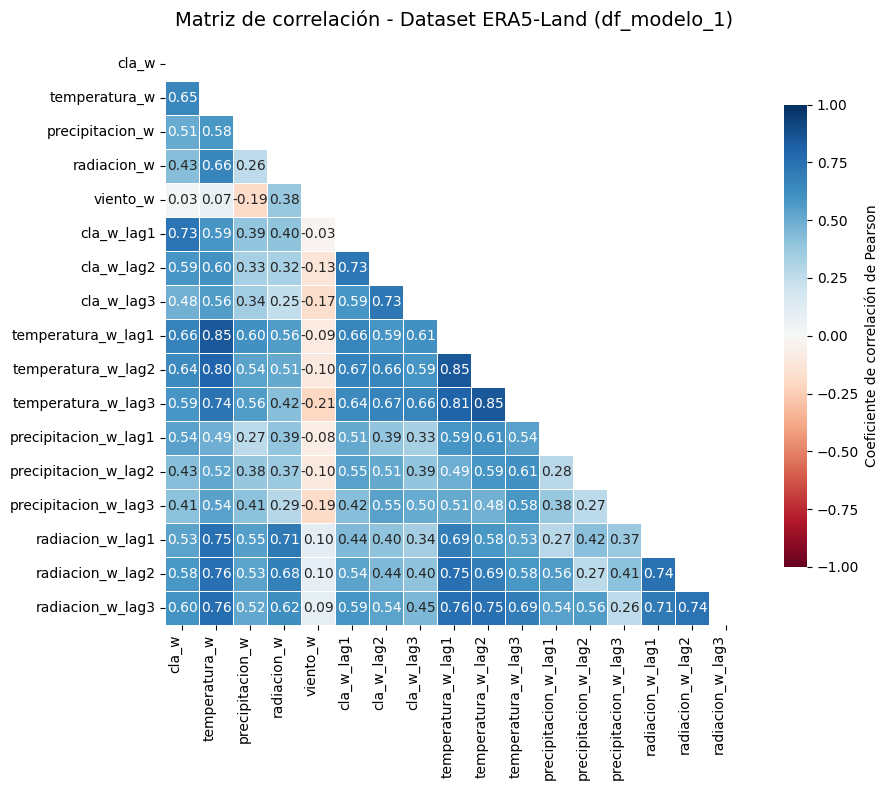

In [ ]:
# GENERAR MATRIZ DE CORRELACIÓN (Dataset ERA5-Land (df_modelo_1))

# Calcular la matriz de correlación de Pearson
corr_matrix_1 = df_modelo_1.corr(method="pearson")

# Crear máscara para ocultar el triángulo superior
mask = np.triu(np.ones_like(corr_matrix_1, dtype=bool))

# Configurar la figura
plt.figure(figsize=(10, 8))

# Generar el mapa de calor con Seaborn
sns.heatmap(corr_matrix_1, mask=mask,
    cmap="RdBu",  # Rojo para negativo, Azul para positivo
    vmin=-1,vmax=1,
    annot=True,  # Pone los valores numéricos dentro de los cuadros
    fmt=".2f",
    linewidths=0.5,  # Líneas divisorias sutiles entre celdas
    cbar_kws={"label": "Coeficiente de correlación de Pearson","shrink": 0.8,},
    square=True,  # Hace que las celdas sean cuadradas perfectas
)

# Estética final
plt.title("Matriz de correlación - Dataset ERA5-Land (df_modelo_1)", fontsize=14, pad=15)
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### **Correlación de la concentración de la clorofila-a con las variables del dataset híbrido (in situ + Era5)**

Este dataset combina los registros de las estaciones in situ de la red MATTEO (variables temperatura y viento) con las variables del reanálisis Era5-Land (variables precipitación y radiación).

Las variables de clorofila, precipitación y radiación (así como sus respectivos retardos) permanecen idénticas a las del dataset anterior (Dataset Era5-Land), y por lo tanto los valores de correlación no cambian.

El aporte fundamental proviene de la incorporación de las mediciones locales (temperatura y viento in situ):

La temperatura in situ y su retardo inmediato presentan alta correlación con la clorofila (temperatura_insitu_w, $r = 0.64$; temperatura_insitu_w_lag1, $r = 0.65$; temperatura_insitu_w_lag2, $r = 0.63$), valores prácticamente equiparables a los observados con las variables térmicas de ERA5 (temperatura_w, $r = 0.65$; temperatura_w_lag1, $r = 0.66$; temperatura_w_lag2, $r = 0.64$).

El viento in situ muestra una correlación baja y negativa (viento_insitu_w, $r = -0.11$), manteniendo la misma tendencia de escasa significancia observada en el viento de ERA5 (viento_w, $r = -0.03$) y justificando su exclusión de los retardos.

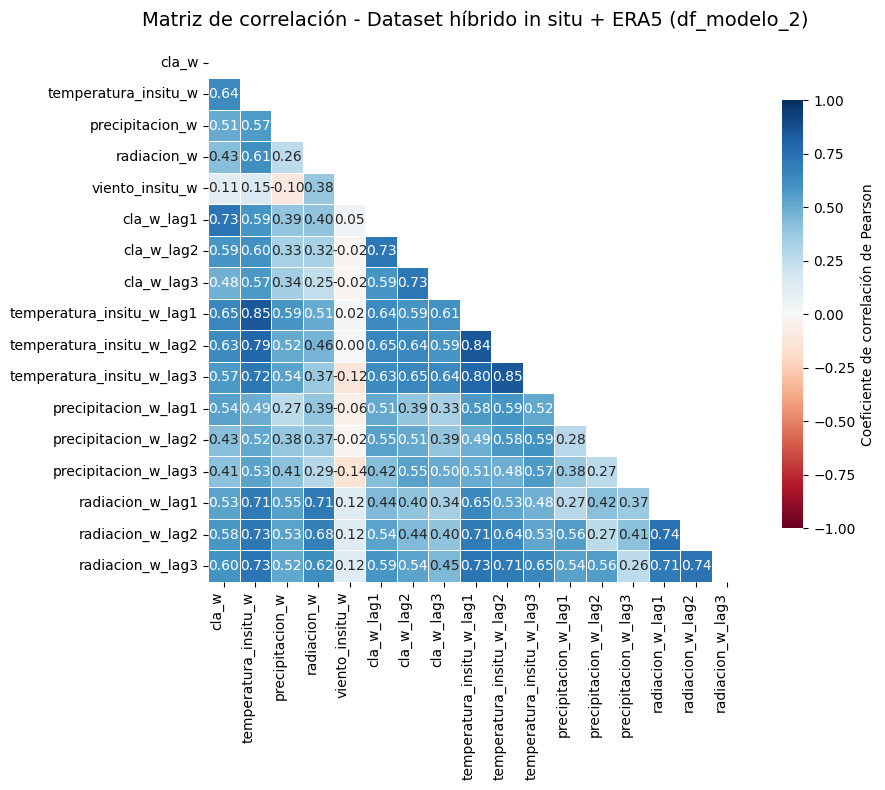

In [ ]:
# GENERAR MATRIZ DE CORRELACIÓN (Dataset híbrido in situ + ERA5 (df_modelo_2))

# Calcular la matriz de correlación de Pearson
corr_matrix_2 = df_modelo_2.corr(method="pearson")

# Crear máscara para ocultar el triángulo superior
mask = np.triu(np.ones_like(corr_matrix_2, dtype=bool))

# Configurar la figura
plt.figure(figsize=(10, 8))

# Generar el mapa de calor con Seaborn
sns.heatmap(corr_matrix_2, mask=mask,
    cmap="RdBu",  # Rojo para negativo, Azul para positivo
    vmin=-1,vmax=1,
    annot=True,  # Pone los valores numéricos dentro de los cuadros
    fmt=".2f",
    linewidths=0.5,  # Líneas divisorias sutiles entre celdas
    cbar_kws={"label": "Coeficiente de correlación de Pearson","shrink": 0.8,},
    square=True,  # Hace que las celdas sean cuadradas perfectas
)

# Estética final
plt.title("Matriz de correlación - Dataset híbrido in situ + ERA5 (df_modelo_2)", fontsize=14, pad=15)
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### **Definición del umbral para eventos de bloom**

Para identificar los episodios críticos de proliferación algal, se adoptó el percentil 75 ($Q_3$) de la serie temporal como umbral de bloom. Este valor se ubicó en 62.72 $\mu$g/L, una cifra prácticamente idéntica a los 63 $\mu$g/L reportados por Germán (2025) en su serie temporal del embalse, lo que respalda la consistencia metodológica de este límite.

In [ ]:
# DEFINIR UMBRAL DE BLOOM

# Definir el umbral de bloom (Percentil 75)
umbral_bloom = np.percentile(df_modelo_1['cla_w'], 75)
print(umbral_bloom)

# Contar número de blooms en la serie temporal
num_blooms = (df_modelo_1["cla_w"] >= umbral_bloom).sum()
print (num_blooms)

62.71534716375
39


### **3.2. Modelos nowcasting**

En esta sección se presentan los resultados correspondientes a la estimación en tiempo real (nowcasting) de la concentración de clorofila-a. Para ello, se implementaron y compararon dos enfoques predictivos: un algoritmo de aprendizaje automático basado en Gradient Boosting (XGBoost) y un modelo de regresión lineal múltiple, utilizando el conjunto de variables derivadas del reanálisis Era5-Land.

En una fase inicial, la incorporación de la totalidad de las variables del reanálisis Era5 generó un bajo rendimiento en el XGBoost debido a la multicolinealidad y el ruido de predictores poco asociados. Para optimizar el rendimiento, se evaluó un subconjunto basado en las $n$ variables con mayor correlación lineal con la clorofila-a (cla_w). Tras probar diversos tamaños, se determinó que el rendimiento óptimo se alcanza con un valor de $n = 4$.

Las variables seleccionadas fueron:
  - cla_w_lag1
  - temperatura_w_lag1
  - temperatura_w
  - temperatura_w_lag2

Este mismo conjunto reducido de variables se mantuvo para el modelo lineal con el fin de garantizar una comparación equitativa.

In [ ]:
# GENERAR SUBCONJUNTO CON LAS N VARIABLES DE MAYOR CORRELACIÓN CON LA CLOROFILA
# Para Nowcasting (Dataset Era5-Land (df_modelo_1))

# Obtener orrelación de todas las variables con la clorofila (cla_w)
corr_cla = corr_matrix_1["cla_w"].abs().sort_values(ascending=False)
print("Correlación con la clorofila:")
print(corr_cla)

# Seleccionar las top N variables con mayor correlación
# (Excluir 'cla_w' porque es la variable objetivo)
n = 4
top_features_nowcast_era = corr_cla.drop("cla_w").head(n).index.tolist()

print(f"\nVariables del dataset Era5-Land seleccionadas para nowcasting: {top_features_nowcast_era}")

Correlación con la clorofila:
cla_w                   1.000000
cla_w_lag1              0.726704
temperatura_w_lag1      0.664153
temperatura_w           0.654285
temperatura_w_lag2      0.638653
radiacion_w_lag3        0.597459
cla_w_lag2              0.589387
temperatura_w_lag3      0.587049
radiacion_w_lag2        0.583948
precipitacion_w_lag1    0.543293
radiacion_w_lag1        0.532202
precipitacion_w         0.505390
cla_w_lag3              0.481176
precipitacion_w_lag2    0.427588
radiacion_w             0.426783
precipitacion_w_lag3    0.410234
viento_w                0.029757
Name: cla_w, dtype: float64

Variables del dataset Era5-Land seleccionadas para nowcasting: ['cla_w_lag1', 'temperatura_w_lag1', 'temperatura_w', 'temperatura_w_lag2']


#### **Evaluación del modelo nowcasting XGBoost (dataset Era5-Land)**

- **Desempeño predictivo continuo:** evaluado mediante validación multisemilla (85/15), el modelo arrojó un  R2  promedio de $0.5847$ ($\pm 0.0819$) y un RMSE promedio de $12.9204$ ($\pm 1.3826$) $\mu$g/L, evidenciando una estabilidad aceptable ante diferentes particiones de los datos.

- **Detección de eventos críticos (blooms):** al evaluar la matriz de confusión y el reporte de clasificación (bajo una semilla de control), el modelo mostró capacidad para identificar los eventos de bloom, alcanzando una precisión de 0.80 y un recall de 0.67 para la clase Bloom, con una exactitud global (accuracy) de 0.88.

- **Seguimiento temporal:** la reconstrucción de la serie temporal con la totalidad de los datos evidencia que el modelo XGBoost es capaz de capturar las tendencias generales y los picos de concentración a lo largo del periodo analizado, a pesar de que subestime los máximos de concentración de clorofila.

In [ ]:
# XGBOOST CON SPLIT ALEATORIO (85-15)
# Para Nowcasting (Dataset Era5-Land (df_modelo_1))

# Definir variables
X = df_modelo_1[top_features_nowcast_era]
y = df_modelo_1["cla_w"]

# Crear vector auxiliar binario para estratificar por eventos de bloom (>= Percentil 75)
# y_strat = (y >= umbral_bloom).astype(int)
# stratify=y_strat

# Lista de semillas
seeds = [42, 123, 456, 789, 1011, 2025, 2026, 333, 777, 999]

# Listas para almacenar las métricas de cada iteración
r2_list = []
rmse_list = []
#best_r2 = -999
#best_seed = None

print("=" * 65)
print("Modelo XGBoost - Nowcasting (Dataset Era5-Land)")
print("=" * 65)

for seed in seeds:
  # Partición aleatoria con la semilla actual (15% test, 85% train)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=seed)

  # Configurar XGBoost con los hiperparámetros
  xgb_model = xgb.XGBRegressor(**xgb_params)

  # Entrenar el modelo
  xgb_model.fit(X_train, y_train)

  # Predicciones y métricas sobre el conjunto de prueba
  y_pred_test = xgb_model.predict(X_test)

  r2_test = r2_score(y_test, y_pred_test)
  rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

  # Guardar resultados
  r2_list.append(r2_test)
  rmse_list.append(rmse_test)

  # Rastrear la mejor semilla
  #if r2_test > best_r2:
    #best_r2 = r2_test
    #best_seed = seed

  print(
      f"Semilla {seed:4d} --> R² Test: {r2_test:.4f} | RMSE Test:"
      f" {rmse_test:.4f} ug/L"
  )

# Calcular promedios y desviación estándar
print("\n" + "=" * 65)
print("Resumen final")
print("=" * 65)
print(f"R² Promedio:   {np.mean(r2_list):.4f} (± {np.std(r2_list):.4f})")
print(f"RMSE Promedio: {np.mean(rmse_list):.4f} (± {np.std(rmse_list):.4f}) ug/L")

#print(best_seed)

Modelo XGBoost - Nowcasting (Dataset Era5-Land)
Semilla   42 --> R² Test: 0.4976 | RMSE Test: 14.4521 ug/L
Semilla  123 --> R² Test: 0.5701 | RMSE Test: 12.3479 ug/L
Semilla  456 --> R² Test: 0.6036 | RMSE Test: 15.5009 ug/L
Semilla  789 --> R² Test: 0.7006 | RMSE Test: 11.8072 ug/L
Semilla 1011 --> R² Test: 0.5944 | RMSE Test: 12.4726 ug/L
Semilla 2025 --> R² Test: 0.7411 | RMSE Test: 10.4087 ug/L
Semilla 2026 --> R² Test: 0.5562 | RMSE Test: 12.2017 ug/L
Semilla  333 --> R² Test: 0.5555 | RMSE Test: 12.6547 ug/L
Semilla  777 --> R² Test: 0.5817 | RMSE Test: 14.0643 ug/L
Semilla  999 --> R² Test: 0.4461 | RMSE Test: 13.2937 ug/L

Resumen final
R² Promedio:   0.5847 (± 0.0819)
RMSE Promedio: 12.9204 (± 1.3826) ug/L


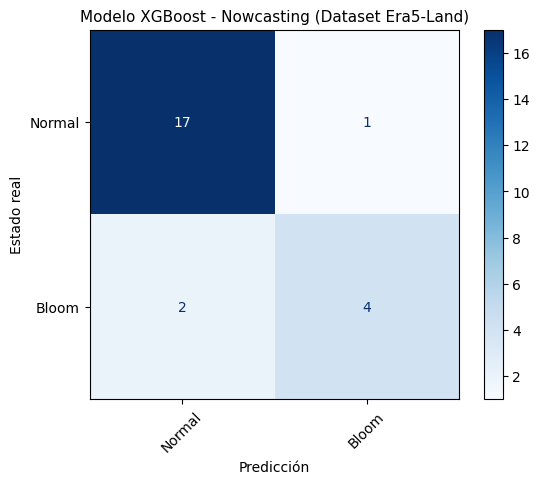

               precision    recall  f1-score   support

Normal (< Q3)       0.89      0.94      0.92        18
Bloom (>= Q3)       0.80      0.67      0.73         6

     accuracy                           0.88        24
    macro avg       0.85      0.81      0.82        24
 weighted avg       0.87      0.88      0.87        24



In [ ]:
# MATRIZ DE CONFUSIÓN
# XGBOOST CON SPLIT ALEATORIO (85-15)
# Para Nowcasting (Dataset Era5-Land (df_modelo_1))

# Obtener partición y predicción e indicar semilla
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Configurar XGBoost con los hiperparámetros
xgb_model = xgb.XGBRegressor(**xgb_params)

# Entrenar el modelo
xgb_model.fit(X_train, y_train)

# Predicciones y métricas sobre el conjunto de prueba
y_pred_test = xgb_model.predict(X_test)

# Binarizar tanto los valores observados de concentración de clorofila como los predichos (0: Normal, 1: Bloom)
y_real_bin = (y_test >= umbral_bloom).astype(int)
y_pred_bin = (y_pred_test >= umbral_bloom).astype(int)

# Crear la matriz de confusión
cm = confusion_matrix(y_real_bin, y_pred_bin)

# Definir las etiquetas de visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Bloom"])

# Graficar
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Modelo XGBoost - Nowcasting (Dataset Era5-Land)",fontsize=11,)
plt.xlabel("Predicción", fontsize=10)
plt.ylabel("Estado real", fontsize=10)
plt.show()

# Obtener métricas de precisión
print(classification_report(y_real_bin, y_pred_bin, target_names=["Normal (< Q3)", "Bloom (>= Q3)"]))

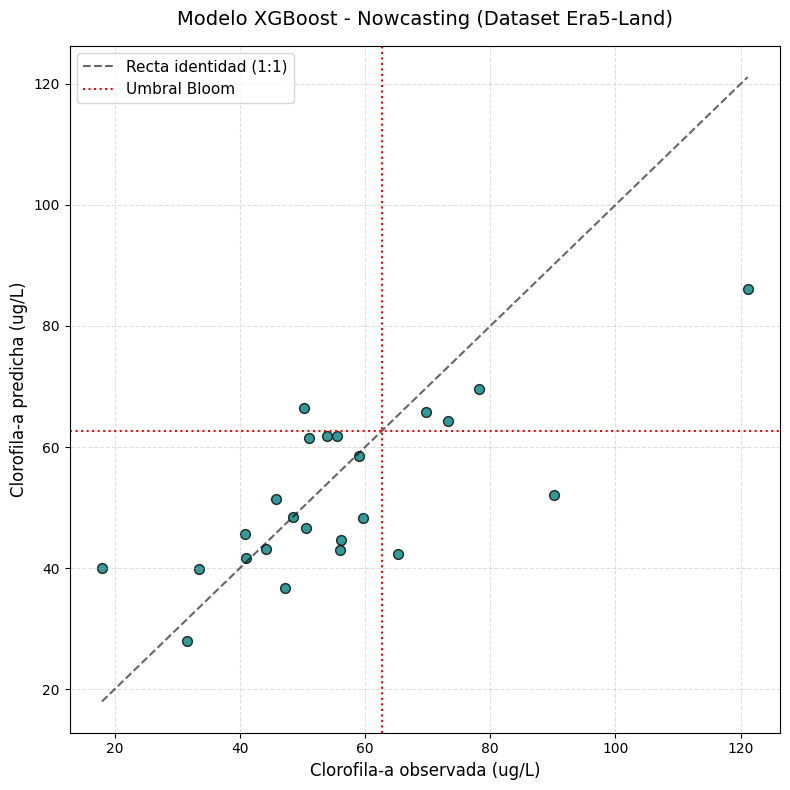

In [ ]:
# DIAGRAMA DE DISPERSIÓN
# XGBOOST CON SPLIT ALEATORIO (85-15)
# Para Nowcasting (Dataset Era5-Land (df_modelo_1))

# Definir tamaño
plt.figure(figsize=(8, 8))

# Graficar los puntos de test
plt.scatter(y_test, y_pred_test, alpha=0.8, color="teal", edgecolor="k", s=50)

# Recta identidad
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.6, label="Recta identidad (1:1)")

# Líneas del umbral de Bloom (Percentil 75)
plt.axvline(umbral_bloom, color="red", linestyle=":", linewidth=1.5, label="Umbral Bloom")
plt.axhline(umbral_bloom, color="red", linestyle=":", linewidth=1.5)

# Etiquetas y estética
plt.xlabel("Clorofila-a observada (ug/L)", fontsize=12)
plt.ylabel("Clorofila-a predicha (ug/L)", fontsize=12)
plt.title("Modelo XGBoost - Nowcasting (Dataset Era5-Land)",fontsize=14,pad=15,)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

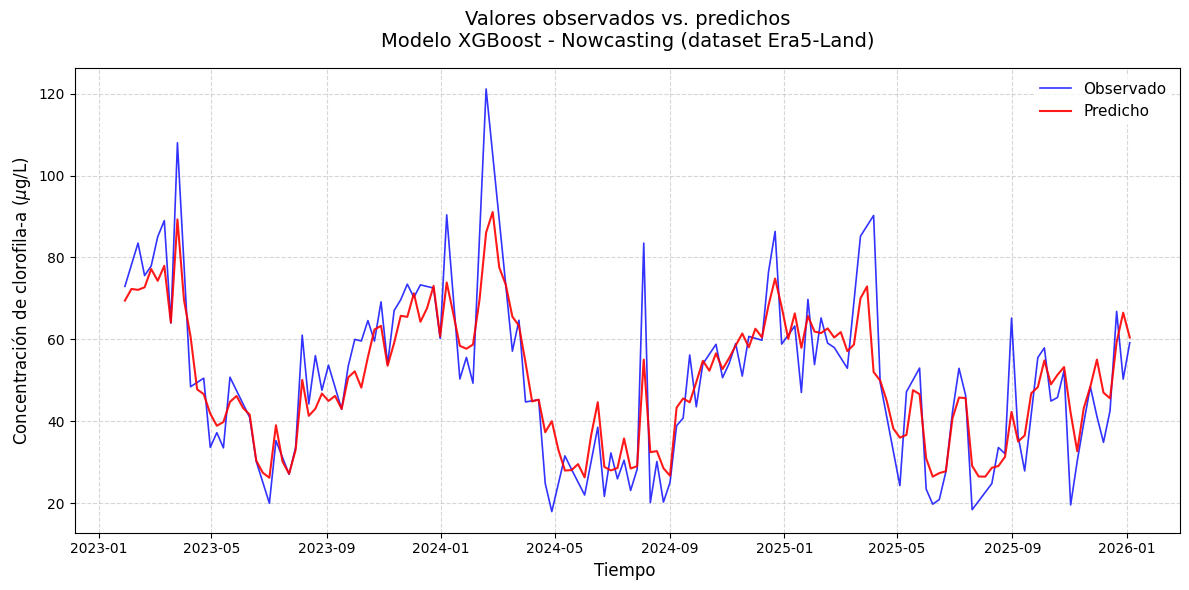

In [ ]:
# VALORES OBSERVADOS VS. PREDICHOS
# XGBOOST CON SPLIT ALEATORIO (85-15)
# Para Nowcasting (Dataset Era5-Land (df_modelo_1))

X = df_modelo_1[top_features_nowcast_era]
y = df_modelo_1["cla_w"]
y_pred = xgb_model.predict(X)

# Configurar la figura
plt.figure(figsize=(12, 6))

# Usar el índice de la base de datos (fecha)
x_axis = df_modelo_1.index

# Graficar serie observada vs modelada
plt.plot(x_axis,y,label="Observado",color="blue",linewidth=1.2,alpha=0.8,)
plt.plot(x_axis,y_pred,label="Predicho",color="red",linewidth=1.5,alpha=0.9,)

# Estética del gráfico
plt.xlabel("Tiempo ", fontsize=12)
plt.ylabel(r"Concentración de clorofila-a ($\mu$g/L)", fontsize=12)
plt.title("Valores observados vs. predichos\nModelo XGBoost - Nowcasting (dataset Era5-Land)",fontsize=14,pad=15,)
plt.legend(fontsize=11, frameon=True, facecolor="white", edgecolor="none")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### **Evaluación del modelo lineal (dataset Era5-Land)**

Como contraste analítico, se implementó un modelo de regresión lineal múltiple utilizando exactamente las mismas 4 variables predictoras seleccionadas por correlación que maximizaban el rendimiento del XGBoost.

- **Desempeño predictivo continuo:** evaluado mediante validación multisemilla (85/15), el modelo lineal obtuvo un R² promedio de $0.5454$ ($\pm 0.1188$) y un RMSE promedio de $13.4994$ ($\pm 2.2526$) $\mu$g/L. Si bien el R² medio se mantiene en un orden similar al del modelo XGBoost, su mayor desviación estándar refleja una sensibilidad más alta a los cambios en la partición de entrenamiento y prueba.

- **Detección de eventos críticos (blooms):** en la clasificación binaria de los eventos de bloom, el modelo lineal mostró mayores limitaciones que el XGBoost, reduciendo su desempeño a una precisión y un recall de 0.50 para la clase crítica, y una exactitud global del 0.75.

- **Seguimiento temporal:** la reconstrucción de la serie temporal con la totalidad de los datos muestra que el modelo lineal exhibe un desfase o retraso temporal (desplazamiento hacia la derecha) respecto a la curva observada, reaccionando de manera tardía ante los cambios abruptos y picos de concentración. Asimismo, presenta una mayor subestimación de los valores extremos en comparación con el enfoque no lineal.

In [ ]:
# MODELO LINEAL CON SPLIT ALEATORIO (85-15)
# Para Nowcasting (Dataset Era5-Land (df_modelo_1))

# Definir variables
X = df_modelo_1[top_features_nowcast_era]
y = df_modelo_1["cla_w"]

# Crear vector auxiliar binario para estratificar por eventos de bloom (>= Percentil 75)
y_strat = (y >= umbral_bloom).astype(int)

# Lista de semillas
seeds = [42, 123, 456, 789, 1011, 2025, 2026, 333, 777, 999]

# Listas para almacenar las métricas de cada iteración
r2_list = []
rmse_list = []
best_r2 = -999
best_seed = None

print("=" * 65)
print("Modelo Lineal - Nowcasting (dataset Era5-Land)")
print("=" * 65)

for seed in seeds:
  # Partición aleatoria con la semilla actual (15% test, 85% train)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=seed)

  # Entrenar el modelo
  X_train_sm = sm.add_constant(X_train)
  X_test_sm = sm.add_constant(X_test)
  model_lineal = sm.OLS(y_train, X_train_sm).fit()

  # Predicciones y métricas sobre el conjunto de prueba
  y_pred_test = model_lineal.predict(X_test_sm)
  r2_test = r2_score(y_test, y_pred_test)
  rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

  # Guardar resultados
  r2_list.append(r2_test)
  rmse_list.append(rmse_test)

  # Rastrear la mejor semilla
  if r2_test > best_r2:
    best_r2 = r2_test
    best_seed = seed

  print(
      f"Semilla {seed:4d} --> R² Test: {r2_test:.4f} | RMSE Test:"
      f" {rmse_test:.4f} ug/L"
  )

# Calcular promedios y desviación estándar
print("\n" + "=" * 65)
print("Resumen final")
print("=" * 65)
print(f"R² Promedio:   {np.mean(r2_list):.4f} (± {np.std(r2_list):.4f})")
print(f"RMSE Promedio: {np.mean(rmse_list):.4f} (±"f" {np.std(rmse_list):.4f}) ug/L")



Modelo Lineal - Nowcasting (dataset Era5-Land)
Semilla   42 --> R² Test: 0.4085 | RMSE Test: 15.6818 ug/L
Semilla  123 --> R² Test: 0.4823 | RMSE Test: 13.5507 ug/L
Semilla  456 --> R² Test: 0.4921 | RMSE Test: 17.5469 ug/L
Semilla  789 --> R² Test: 0.5502 | RMSE Test: 14.4726 ug/L
Semilla 1011 --> R² Test: 0.6676 | RMSE Test: 11.2917 ug/L
Semilla 2025 --> R² Test: 0.7907 | RMSE Test: 9.3586 ug/L
Semilla 2026 --> R² Test: 0.6327 | RMSE Test: 11.1006 ug/L
Semilla  333 --> R² Test: 0.4355 | RMSE Test: 14.2604 ug/L
Semilla  777 --> R² Test: 0.5866 | RMSE Test: 13.9831 ug/L
Semilla  999 --> R² Test: 0.4075 | RMSE Test: 13.7481 ug/L

Resumen final
R² Promedio:   0.5454 (± 0.1188)
RMSE Promedio: 13.4994 (± 2.2526) ug/L


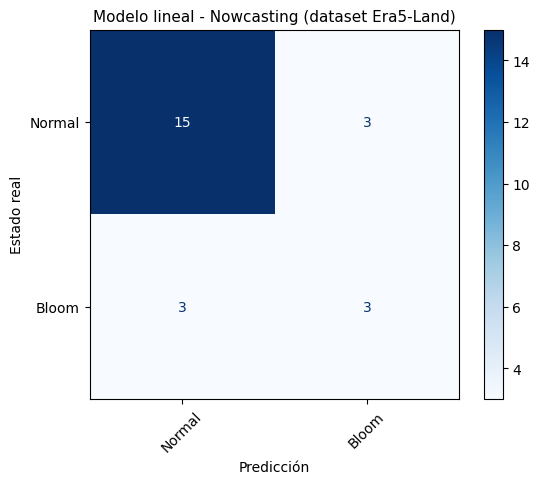

               precision    recall  f1-score   support

Normal (< Q3)       0.83      0.83      0.83        18
Bloom (>= Q3)       0.50      0.50      0.50         6

     accuracy                           0.75        24
    macro avg       0.67      0.67      0.67        24
 weighted avg       0.75      0.75      0.75        24



In [ ]:
# MATRIZ DE CONFUSIÓN
# MODELO LINEAL CON SPLIT ALEATORIO (85-15)
# Para Nowcasting (Dataset Era5-Land (df_modelo_1))

# Obtener partición y predicción e indicar semilla
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Entrenar el modelo
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)
model_lineal = sm.OLS(y_train, X_train_sm).fit()

# Predicciones y métricas sobre el conjunto de prueba
y_pred_test = model_lineal.predict(X_test_sm)

# Binarizar tanto los valores observados de concentración de clorofila como los predichos (0: Normal, 1: Bloom)
y_real_bin = (y_test >= umbral_bloom).astype(int)
y_pred_bin = (y_pred_test >= umbral_bloom).astype(int)

# Crear la matriz de confusión
cm = confusion_matrix(y_real_bin, y_pred_bin)

# Definir las etiquetas de visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Bloom"])

# Graficar
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Modelo lineal - Nowcasting (dataset Era5-Land)",fontsize=11,)
plt.xlabel("Predicción", fontsize=10)
plt.ylabel("Estado real", fontsize=10)
plt.show()

# Obtener métricas de precisión
print(classification_report(y_real_bin, y_pred_bin, target_names=["Normal (< Q3)", "Bloom (>= Q3)"]))

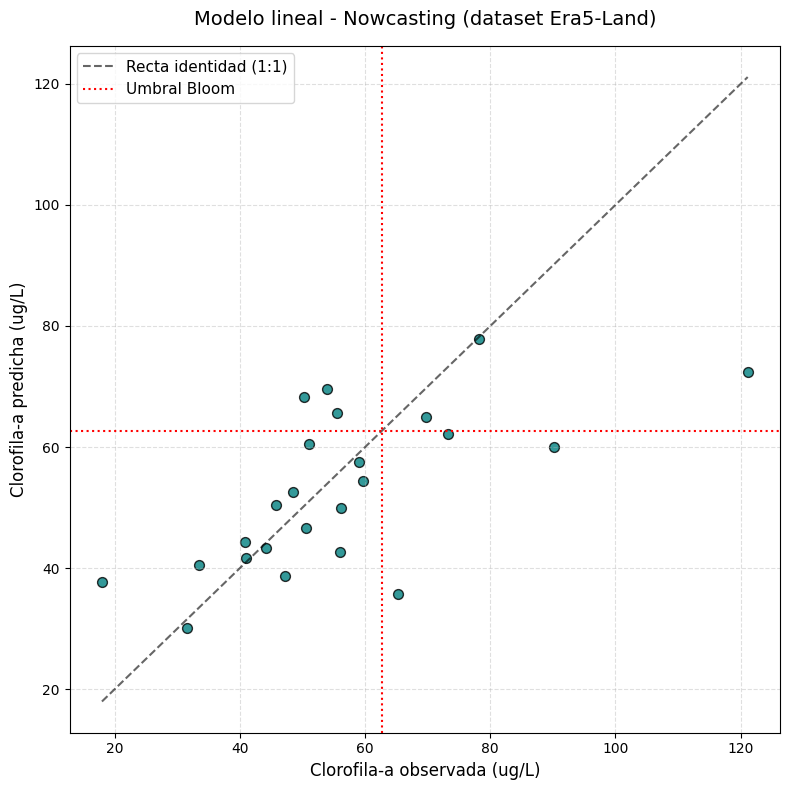

In [ ]:
# DIAGRAMA DE DISPERSIÓN
# MODELO LINEAL CON SPLIT ALEATORIO (85-15)
# Para Nowcasting (Dataset Era5-Land (df_modelo_1))

# Definir tamaño
plt.figure(figsize=(8, 8))

# Graficar los puntos de test
plt.scatter(y_test, y_pred_test, alpha=0.8, color="teal", edgecolor="k", s=50)

# Recta identidad
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.6, label="Recta identidad (1:1)")

# Líneas del umbral de Bloom (Percentil 75)
plt.axvline(umbral_bloom, color="red", linestyle=":", linewidth=1.5, label="Umbral Bloom")
plt.axhline(umbral_bloom, color="red", linestyle=":", linewidth=1.5)

# Etiquetas y estética
plt.xlabel("Clorofila-a observada (ug/L)", fontsize=12)
plt.ylabel("Clorofila-a predicha (ug/L)", fontsize=12)
plt.title("Modelo lineal - Nowcasting (dataset Era5-Land)",fontsize=14,pad=15,)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

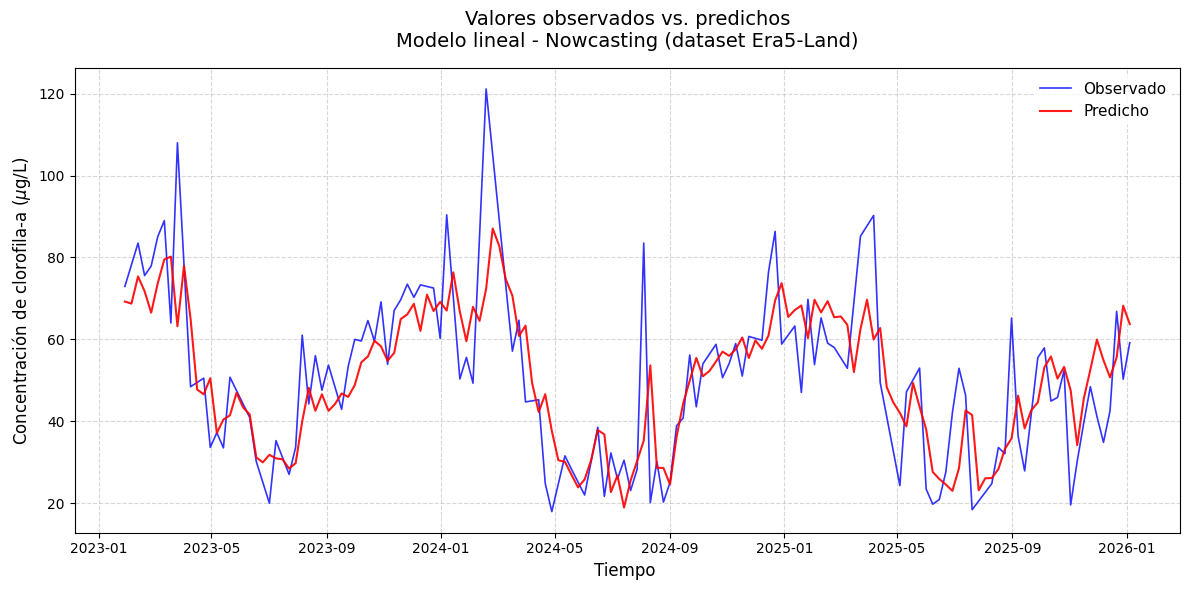

In [ ]:
# VALORES OBSERVADOS VS. PREDICHOS
# MODELO LINEAL CON SPLIT ALEATORIO (85-15)
# Para Nowcasting (Dataset Era5-Land (df_modelo_1))

X_final = sm.add_constant(X[top_features_nowcast_era])
y = df_modelo_1["cla_w"]
y_pred = model_lineal.predict(X_final)

# Configurar la figura
plt.figure(figsize=(12, 6))

# Usar el índice de la base de datos (fecha)
x_axis = df_modelo_1.index

# Graficar serie observada vs modelada
plt.plot(x_axis,y,label="Observado",color="blue",linewidth=1.2,alpha=0.8,)
plt.plot(x_axis,y_pred,label="Predicho",color="red",linewidth=1.5,alpha=0.9,)

# Estética del gráfico
plt.xlabel("Tiempo ", fontsize=12)
plt.ylabel(r"Concentración de clorofila-a ($\mu$g/L)", fontsize=12)
plt.title("Valores observados vs. predichos\nModelo lineal - Nowcasting (dataset Era5-Land)",fontsize=14,pad=15,)
plt.legend(fontsize=11, frameon=True, facecolor="white", edgecolor="none")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### **3.3. Modelos forecasting**

En esta sección se presentan los resultados correspondientes a la predicción anticipada (forecasting) de la concentración de clorofila-a. Para ello, se evaluaron dos modelos XGBoost utilizando conjuntos de predictores optimizados: uno basado en el dataset Era5-Land y otro en el dataset híbrido (variables locales in situ y de Era5-Land).

#### **Evaluación del modelo forecasting XGBoost - dataset Era5-Land**

Para este escenario de forecasting, se restringieron las variables meteorológicas a partir del retardo de segundo orden (lag 2) hacia atrás, en concordancia con la disponibilidad operativa de los datos.

Al evaluar el rendimiento según el tamaño del subconjunto de variables con mayor correlación con la clorofila-a, se determinó un rendimiento óptimo con un valor de $n = 3$. Las variables seleccionadas fueron:

- cla_w_lag1
- temperatura_w_lag2
- radiacion_w_lag3

- **Desempeño predictivo continuo:** evaluado mediante validación multisemilla (85/15), el modelo arrojó un $R^2$ promedio de $0.4707$ ($\pm 0.1222$) y un RMSE promedio de $14.5653$ ($\pm 1.9372$) $\mu$g/L, reflejando una reducción esperada en la capacidad explicativa en comparación con el modelo nowcasting.

- **Detección de eventos críticos (blooms):** al evaluar la matriz de confusión y el reporte de clasificación (bajo una semilla representativa), el modelo mostró capacidad para identificar los eventos de bloom, alcanzando una precisión de $0.71$ y un recall de $0.71$, con una exactitud global (accuracy) del $0.83$.

- **Seguimiento temporal:** la reconstrucción de la serie temporal con la totalidad de los datos demuestra que el modelo es capaz de capturar la estacionalidad y las tendencias generales del embalse, aunque subestima los picos más altos de concentración.   

In [ ]:
# GENERAR SUBCONJUNTO CON LAS N VARIABLES DE MAYOR CORRELACIÓN CON LA CLOROFILA
# Para Forecasting (Dataset Era5-Land (df_modelo_1))

# Definir el conjunto de variables permitidas para forecasting
variables_forecast_disponibles = ["cla_w_lag1","cla_w_lag2","cla_w_lag3","temperatura_w_lag2","temperatura_w_lag3",
                                  "precipitacion_w_lag2","precipitacion_w_lag3","radiacion_w_lag2","radiacion_w_lag3",]

# Obtener correlación sólo para las variables permitidas
corr_forecast = (corr_matrix_1.loc[variables_forecast_disponibles, "cla_w"].abs().sort_values(ascending=False))
print("Correlación con la clorofila - variables disponibles para forecasting:")
print(corr_forecast)

# Seleccionar las top N con mayor correlación
n = 3
top_features_forecast_era = corr_forecast.head(n).index.tolist()
print(f"\nVariables del dataset Era5-Land seleccionadas para forecasting: {top_features_forecast_era}")

Correlación con la clorofila - variables disponibles para forecasting:
cla_w_lag1              0.726704
temperatura_w_lag2      0.638653
radiacion_w_lag3        0.597459
cla_w_lag2              0.589387
temperatura_w_lag3      0.587049
radiacion_w_lag2        0.583948
cla_w_lag3              0.481176
precipitacion_w_lag2    0.427588
precipitacion_w_lag3    0.410234
Name: cla_w, dtype: float64

Variables del dataset Era5-Land seleccionadas para forecasting: ['cla_w_lag1', 'temperatura_w_lag2', 'radiacion_w_lag3']


In [ ]:
# XGBOOST CON SPLIT ALEATORIO (85-15)
# Para Forecasting (Dataset Era5-Land (df_modelo_1))

# Definir variables
X = df_modelo_1[top_features_forecast_era]
y = df_modelo_1["cla_w"]

# Crear vector auxiliar binario para estratificar por eventos de bloom (>= Percentil 75)
# y_strat = (y >= umbral_bloom).astype(int)

# Lista de semillas
seeds = [42, 123, 456, 789, 1011, 2025, 2026, 333, 777, 999]

# Listas para almacenar las métricas de cada iteración
r2_list = []
rmse_list = []
#best_r2 = -999
#best_seed = None

print("=" * 65)
print("Modelo XGBoost - Forecasting (dataset Era5-Land)")
print("=" * 65)

for seed in seeds:
  # Partición aleatoria con la semilla actual (15% test, 85% train)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=seed)

  # Configurar XGBoost con los hiperparámetros
  xgb_model = xgb.XGBRegressor(**xgb_params)

  # Entrenar el modelo
  xgb_model.fit(X_train, y_train)

  # Predicciones y métricas sobre el conjunto de prueba
  y_pred_test = xgb_model.predict(X_test)

  r2_test = r2_score(y_test, y_pred_test)
  rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

  # Guardar resultados
  r2_list.append(r2_test)
  rmse_list.append(rmse_test)

  # Rastrear la mejor semilla
  #if r2_test > best_r2:
    #best_r2 = r2_test
    #best_seed = seed

  print(f"Semilla {seed:4d} --> R² Test: {r2_test:.4f} | RMSE Test:"f" {rmse_test:.4f} ug/L")

# Calcular promedios y desviación estándar
print("\n" + "=" * 65)
print("Resumen final")
print("=" * 65)
print(f"R² Promedio:   {np.mean(r2_list):.4f} (± {np.std(r2_list):.4f})")
print(f"RMSE Promedio: {np.mean(rmse_list):.4f} (± {np.std(rmse_list):.4f}) ug/L")

#print(best_seed)

Modelo XGBoost - Forecasting (dataset Era5-Land)
Semilla   42 --> R² Test: 0.3722 | RMSE Test: 16.1551 ug/L
Semilla  123 --> R² Test: 0.3754 | RMSE Test: 14.8840 ug/L
Semilla  456 --> R² Test: 0.4731 | RMSE Test: 17.8721 ug/L
Semilla  789 --> R² Test: 0.6600 | RMSE Test: 12.5831 ug/L
Semilla 1011 --> R² Test: 0.6186 | RMSE Test: 12.0955 ug/L
Semilla 2025 --> R² Test: 0.6643 | RMSE Test: 11.8520 ug/L
Semilla 2026 --> R² Test: 0.4392 | RMSE Test: 13.7170 ug/L
Semilla  333 --> R² Test: 0.3324 | RMSE Test: 15.5075 ug/L
Semilla  777 --> R² Test: 0.4056 | RMSE Test: 16.7662 ug/L
Semilla  999 --> R² Test: 0.3662 | RMSE Test: 14.2201 ug/L

Resumen final
R² Promedio:   0.4707 (± 0.1222)
RMSE Promedio: 14.5653 (± 1.9372) ug/L


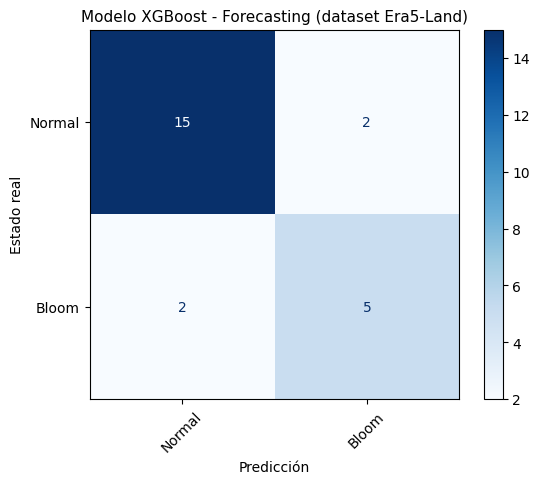

               precision    recall  f1-score   support

Normal (< Q3)       0.88      0.88      0.88        17
Bloom (>= Q3)       0.71      0.71      0.71         7

     accuracy                           0.83        24
    macro avg       0.80      0.80      0.80        24
 weighted avg       0.83      0.83      0.83        24



In [ ]:
# MATRIZ DE CONFUSIÓN
# XGBOOST CON SPLIT ALEATORIO (85-15)
# Para Forecasting (Dataset Era5-Land (df_modelo_1))

# Obtener partición y predicción e indicar semilla
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=456)

# Configurar XGBoost con los hiperparámetros
xgb_model = xgb.XGBRegressor(**xgb_params)

# Entrenar el modelo
xgb_model.fit(X_train, y_train)

# Predicciones y métricas sobre el conjunto de prueba
y_pred_test = xgb_model.predict(X_test)

# Binarizar tanto los valores observados de concentración de clorofila como los predichos (0: Normal, 1: Bloom)
y_real_bin = (y_test >= umbral_bloom).astype(int)
y_pred_bin = (y_pred_test >= umbral_bloom).astype(int)

# Crear la matriz de confusión
cm = confusion_matrix(y_real_bin, y_pred_bin)

# Definir las etiquetas de visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Bloom"])

# Graficar
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Modelo XGBoost - Forecasting (dataset Era5-Land)",fontsize=11,)
plt.xlabel("Predicción", fontsize=10)
plt.ylabel("Estado real", fontsize=10)
plt.show()

# Obtener métricas de precisión
print(classification_report(y_real_bin, y_pred_bin, target_names=["Normal (< Q3)", "Bloom (>= Q3)"]))

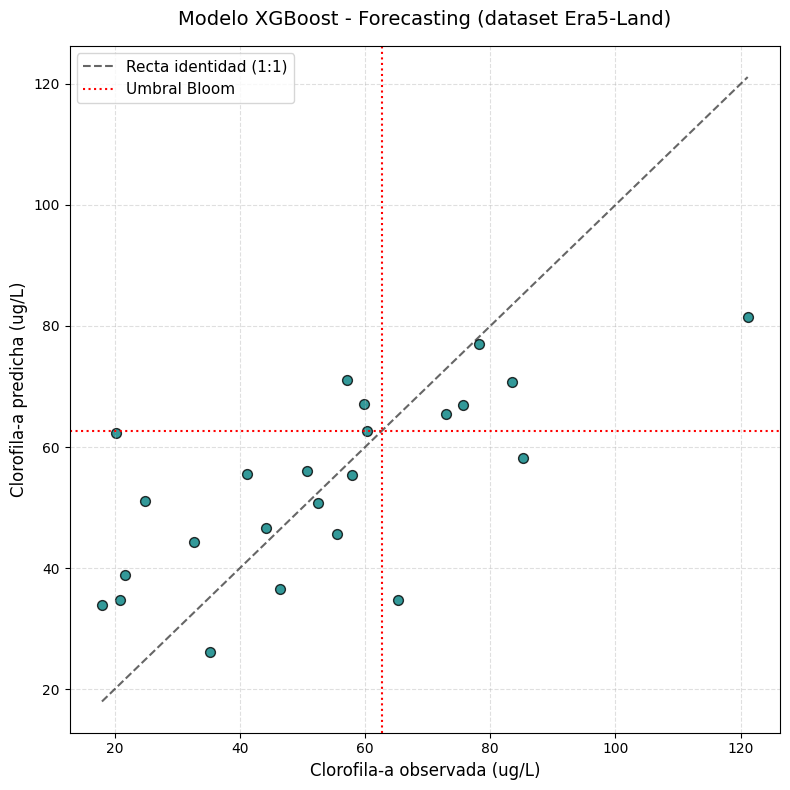

In [ ]:
# DIAGRAMA DE DISPERSIÓN
# XGBOOST CON SPLIT ALEATORIO (85-15)
# Para Forecasting (Dataset Era5-Land (df_modelo_1))

# Definir tamaño
plt.figure(figsize=(8, 8))

# Graficar los puntos de test
plt.scatter(y_test, y_pred_test, alpha=0.8, color="teal", edgecolor="k", s=50)

# Recta identidad
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.6, label="Recta identidad (1:1)")

# Líneas del umbral de Bloom (Percentil 75)
plt.axvline(umbral_bloom, color="red", linestyle=":", linewidth=1.5, label="Umbral Bloom")
plt.axhline(umbral_bloom, color="red", linestyle=":", linewidth=1.5)

# Etiquetas y estética
plt.xlabel("Clorofila-a observada (ug/L)", fontsize=12)
plt.ylabel("Clorofila-a predicha (ug/L)", fontsize=12)
plt.title("Modelo XGBoost - Forecasting (dataset Era5-Land)",fontsize=14,pad=15,)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

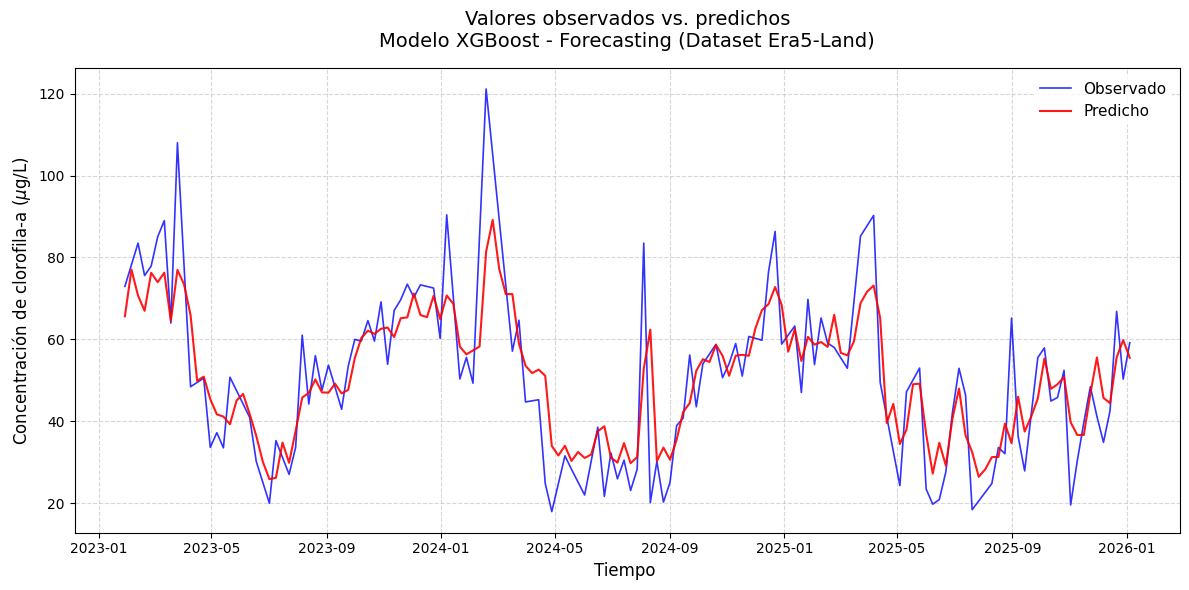

In [ ]:
# VALORES OBSERVADOS VS. PREDICHOS
# XGBOOST CON SPLIT ALEATORIO (85-15)
# Para Forecasting (Dataset Era5-Land (df_modelo_1))

X = df_modelo_1[top_features_forecast_era]
y = df_modelo_1["cla_w"]
y_pred = xgb_model.predict(X)

# Configurar la figura
plt.figure(figsize=(12, 6))

# Usar el índice de la base de datos (fecha)
x_axis = df_modelo_1.index

# Graficar serie observada vs modelada
plt.plot(x_axis,y,label="Observado",color="blue",linewidth=1.2,alpha=0.8,)
plt.plot(x_axis,y_pred,label="Predicho",color="red",linewidth=1.5,alpha=0.9,)

# Estética del gráfico
plt.xlabel("Tiempo ", fontsize=12)
plt.ylabel(r"Concentración de clorofila-a ($\mu$g/L)", fontsize=12)
plt.title("Valores observados vs. predichos\nModelo XGBoost - Forecasting (Dataset Era5-Land)",fontsize=14,pad=15,)
plt.legend(fontsize=11, frameon=True, facecolor="white", edgecolor="none")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### **Evaluación del modelo forecasting XGBoost - dataset híbrido (in situ + Era5-Land)**

Para este segundo escenario de forecasting, empleando el dataset híbrido (que integra registros térmicos locales junto con la precipitación y la radiación de ERA5-Land), se aplicaron restricciones específicas: se evaluó la temperatura local a partir del retardo de primer orden (lag 1) hacia atrás, mientras que para las variables de reanálisis se mantuvo el límite a partir del retardo de segundo orden (lag 2).

Al evaluar el rendimiento según el tamaño del subconjunto de variables con mayor correlación con la clorofila-a, se determinó un rendimiento óptimo con un valor de $n = 3$. Las variables seleccionadas fueron:
- cla_w_lag1
- temperatura_insitu_w_lag1
- temperatura_insitu_w_lag2

- **Desempeño predictivo continuo:** el modelo obtuvo un $R^2$ promedio de $0.4747$ ($\pm 0.1409$) y un RMSE promedio de $14.4684$ ($\pm 2.0301$) $\mu$g/L. Estos valores son prácticamente idénticos a los obtenidos con el dataset Era5-Land, indicando que la incorporación de la temperatura in situ mantiene un nivel de desempeño equivalente y que la disponibilidad del retardo de primer orden de la temperatura no modifica el rendimiento del algoritmo.

- **Detección de eventos críticos (blooms):** bajo la misma semilla de control usada en el primer escenario de forecasting, la matriz de confusión reportó una precisión de $0.62$ y un recall de $0.71$ para la clase Bloom, con una exactitud global del $0.79$.

- **Seguimiento temporal:** la reconstrucción de la serie temporal con la totalidad de los datos muestra que el modelo reproduce de manera consistente el comportamiento dinámico del sistema, acompañando adecuadamente las fluctuaciones de clorofila-a.

In [ ]:
# GENERAR SUBCONJUNTO CON LAS N VARIABLES DE MAYOR CORRELACIÓN CON LA CLOROFILA
# Para Forecasting (Dataset Híbrido In situ + ERA5 (df_modelo_2))

# Definir el conjunto de variables permitidas para forecasting
variables_forecast_disponibles_2 = ["cla_w_lag1","cla_w_lag2","cla_w_lag3",
                                         "temperatura_insitu_w_lag1", "temperatura_insitu_w_lag2","temperatura_insitu_w_lag3",
                                         "precipitacion_w_lag2","precipitacion_w_lag3","radiacion_w_lag2","radiacion_w_lag3",]

# Obtener correlación sólo para las variables permitidas
corr_forecast = (corr_matrix_2.loc[variables_forecast_disponibles_2, "cla_w"].abs().sort_values(ascending=False))
print("Correlación con la clorofila - variables disponibles para forecasting:")
print(corr_forecast)

# Seleccionar las top N con mayor correlación
n = 3
top_features_forecast_hibrido = corr_forecast.head(n).index.tolist()
print(f"\nVariables seleccionadas para forecasting: {top_features_forecast_hibrido}")

Correlación con la clorofila - variables disponibles para forecasting:
cla_w_lag1                   0.726704
temperatura_insitu_w_lag1    0.649055
temperatura_insitu_w_lag2    0.629729
radiacion_w_lag3             0.597459
cla_w_lag2                   0.589387
radiacion_w_lag2             0.583948
temperatura_insitu_w_lag3    0.574043
cla_w_lag3                   0.481176
precipitacion_w_lag2         0.427588
precipitacion_w_lag3         0.410234
Name: cla_w, dtype: float64

Variables seleccionadas para forecasting: ['cla_w_lag1', 'temperatura_insitu_w_lag1', 'temperatura_insitu_w_lag2']


In [ ]:
# XGBOOST CON SPLIT ALEATORIO (85-15)
# Para Forecasting (Dataset híbrido (df_modelo_2))

# Definir variables
X = df_modelo_2[top_features_forecast_hibrido]
y = df_modelo_2["cla_w"]

# Crear vector auxiliar binario para estratificar por eventos de bloom (>= Percentil 75)
y_strat = (y >= umbral_bloom).astype(int)

# Lista de semillas
seeds = [42, 123, 456, 789, 1011, 2025, 2026, 333, 777, 999]

# Listas para almacenar las métricas de cada iteración
r2_list = []
rmse_list = []
#best_r2 = -999
#best_seed = None

print("=" * 65)
print("Modelo XGBoost - Forecasting (dataset híbrido)")
print("=" * 65)

for seed in seeds:
  # Partición aleatoria con la semilla actual (15% test, 85% train)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=seed)

  # Configurar XGBoost con los hiperparámetros
  xgb_model = xgb.XGBRegressor(**xgb_params)

  # Entrenar el modelo
  xgb_model.fit(X_train, y_train)

  # Predicciones y métricas sobre el conjunto de prueba
  y_pred_test = xgb_model.predict(X_test)

  r2_test = r2_score(y_test, y_pred_test)
  rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

  # Guardar resultados
  r2_list.append(r2_test)
  rmse_list.append(rmse_test)

  # Rastrear la mejor semilla
  #if r2_test > best_r2:
    #best_r2 = r2_test
    #best_seed = seed

  print(
      f"Semilla {seed:4d} --> R² Test: {r2_test:.4f} | RMSE Test:"
      f" {rmse_test:.4f} ug/L"
  )

# Calcular promedios y desviación estándar
print("\n" + "=" * 65)
print("Resumen final")
print("=" * 65)
print(f"R² Promedio:   {np.mean(r2_list):.4f} (± {np.std(r2_list):.4f})")
print(f"RMSE Promedio: {np.mean(rmse_list):.4f} (± {np.std(rmse_list):.4f}) ug/L")

#print(best_seed)

Modelo XGBoost - Forecasting (dataset híbrido)
Semilla   42 --> R² Test: 0.4100 | RMSE Test: 15.6620 ug/L
Semilla  123 --> R² Test: 0.3202 | RMSE Test: 15.5273 ug/L
Semilla  456 --> R² Test: 0.4591 | RMSE Test: 18.1077 ug/L
Semilla  789 --> R² Test: 0.5936 | RMSE Test: 13.7563 ug/L
Semilla 1011 --> R² Test: 0.6785 | RMSE Test: 11.1046 ug/L
Semilla 2025 --> R² Test: 0.6857 | RMSE Test: 11.4679 ug/L
Semilla 2026 --> R² Test: 0.4971 | RMSE Test: 12.9891 ug/L
Semilla  333 --> R² Test: 0.3385 | RMSE Test: 15.4371 ug/L
Semilla  777 --> R² Test: 0.5126 | RMSE Test: 15.1822 ug/L
Semilla  999 --> R² Test: 0.2518 | RMSE Test: 15.4495 ug/L

Resumen final
R² Promedio:   0.4747 (± 0.1409)
RMSE Promedio: 14.4684 (± 2.0301) ug/L


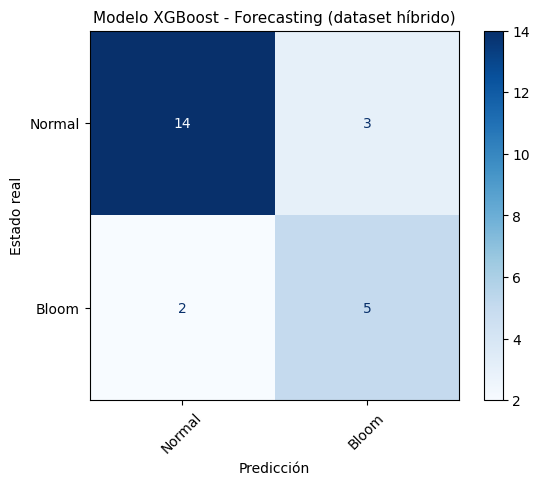

               precision    recall  f1-score   support

Normal (< Q3)       0.88      0.82      0.85        17
Bloom (>= Q3)       0.62      0.71      0.67         7

     accuracy                           0.79        24
    macro avg       0.75      0.77      0.76        24
 weighted avg       0.80      0.79      0.80        24



In [ ]:
# MATRIZ DE CONFUSIÓN
# XGBOOST CON SPLIT ALEATORIO (85-15)
# Para Forecasting (Dataset híbrido (df_modelo_2))

# Obtener partición y predicción usando la mejor semilla
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=456)

# Configurar XGBoost con los hiperparámetros
xgb_model = xgb.XGBRegressor(**xgb_params)

# Entrenar el modelo
xgb_model.fit(X_train, y_train)

# Predicciones y métricas sobre el conjunto de prueba
y_pred_test = xgb_model.predict(X_test)

# Binarizar tanto los valores observados de concentración de clorofila como los predichos (0: Normal, 1: Bloom)
y_real_bin = (y_test >= umbral_bloom).astype(int)
y_pred_bin = (y_pred_test >= umbral_bloom).astype(int)

# Crear la matriz de confusión
cm = confusion_matrix(y_real_bin, y_pred_bin)

# Definir las etiquetas de visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Bloom"])

# Graficar
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Modelo XGBoost - Forecasting (dataset híbrido)",fontsize=11,)
plt.xlabel("Predicción", fontsize=10)
plt.ylabel("Estado real", fontsize=10)
plt.show()

# Obtener métricas de precisión
print(classification_report(y_real_bin, y_pred_bin, target_names=["Normal (< Q3)", "Bloom (>= Q3)"]))

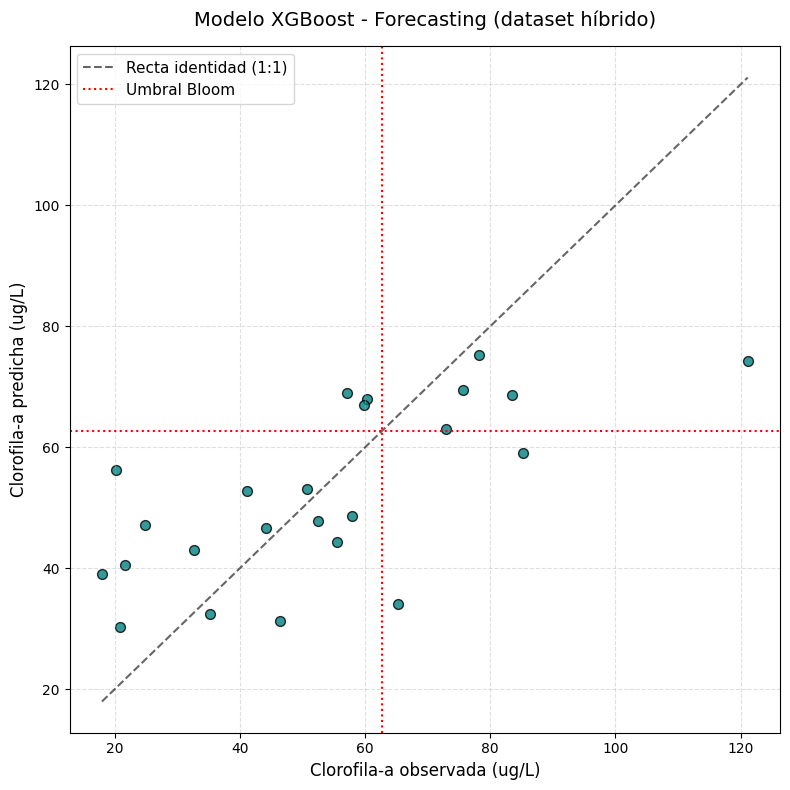

In [ ]:
# DIAGRAMA DE DISPERSIÓN
# XGBOOST CON SPLIT ALEATORIO (85-15)
# Para Forecasting (Dataset híbrido (df_modelo_2))

# Definir tamaño
plt.figure(figsize=(8, 8))

# Graficar los puntos de test
plt.scatter(y_test, y_pred_test, alpha=0.8, color="teal", edgecolor="k", s=50)

# Recta identidad
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.6, label="Recta identidad (1:1)")

# Líneas del umbral de Bloom (Percentil 75)
plt.axvline(umbral_bloom, color="red", linestyle=":", linewidth=1.5, label="Umbral Bloom")
plt.axhline(umbral_bloom, color="red", linestyle=":", linewidth=1.5)

# Etiquetas y estética
plt.xlabel("Clorofila-a observada (ug/L)", fontsize=12)
plt.ylabel("Clorofila-a predicha (ug/L)", fontsize=12)
plt.title("Modelo XGBoost - Forecasting (dataset híbrido)",fontsize=14,pad=15,)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

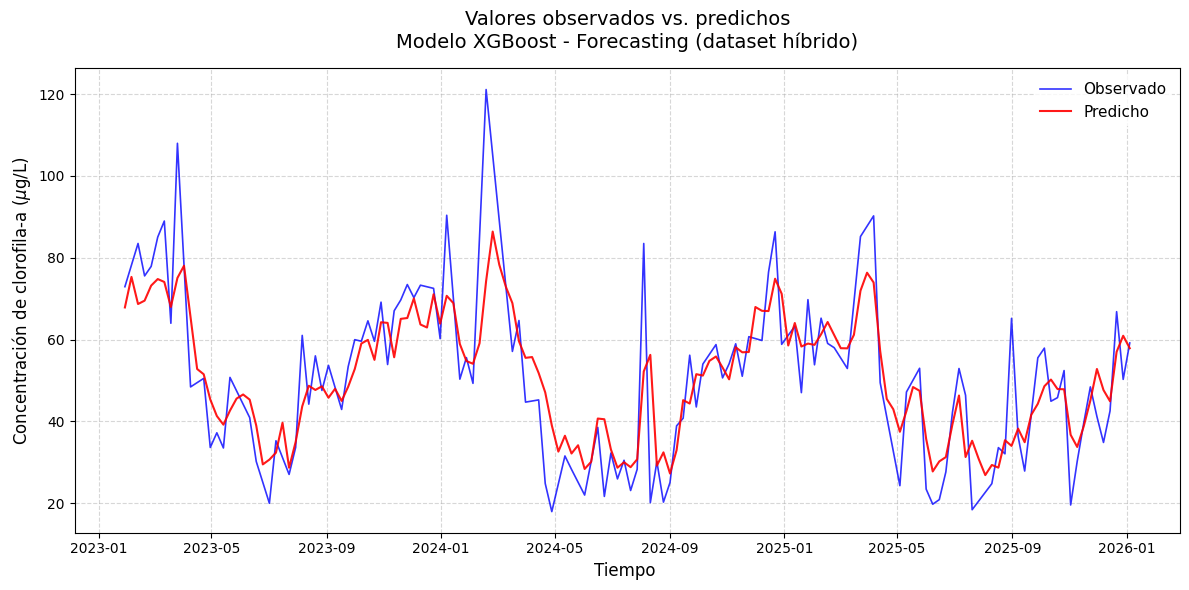

In [ ]:
# VALORES OBSERVADOS VS. PREDICHOS
# XGBOOST CON SPLIT ALEATORIO (85-15)
# Para Forecasting (Dataset híbrido (df_modelo_2))

X = df_modelo_2[top_features_forecast_hibrido]
y = df_modelo_2["cla_w"]
y_pred = xgb_model.predict(X)

# Configurar la figura
plt.figure(figsize=(12, 6))

# Usar el índice de la base de datos (fecha)
x_axis = df_modelo_2.index

# Graficar serie observada vs modelada
plt.plot(x_axis,y,label="Observado",color="blue",linewidth=1.2,alpha=0.8,)
plt.plot(x_axis,y_pred,label="Predicho",color="red",linewidth=1.5,alpha=0.9,)

# Estética del gráfico
plt.xlabel("Tiempo ", fontsize=12)
plt.ylabel(r"Concentración de clorofila-a ($\mu$g/L)", fontsize=12)
plt.title("Valores observados vs. predichos\nModelo XGBoost - Forecasting (dataset híbrido)",fontsize=14,pad=15,)
plt.legend(fontsize=11, frameon=True, facecolor="white", edgecolor="none")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### **Predicción a partir del modelo forecasting XGBoost con dataset Era5-Land**

Con el fin de probar la implementación de los modelos de forecasting evaluados anteriormente, se desarrolló un flujo de trabajo para predecir la concentración de clorofila-a en el embalse San Roque a una semana. Para ello, se seleccionó el modelo XGBoost entrenado con el dataset ERA5-Land, que utiliza como variables de entrada `cla_w_lag1`, `temperatura_w_lag2` y `radiacion_w_lag3`.

El flujo de trabajo comprende los siguientes pasos:

1) **Entrenamiento del modelo**: se entrenó el modelo XGBoost utilizando el total de los datos disponibles del dataset ERA5-Land para el periodo enero 2023-enero 2026.

2) **Obtención de las variables de entrada**: se obtuvo la concentración de clorofila-a en el embalse correspondiente a la semana previa al período a evaluar (cla_w_lag1) a partir de imágenes de Sentinel-2. Asimismo, se obtuvieron la temperatura correspondiente a dos semanas previas (temperatura_w_lag2) y la radiación correspondiente a tres semanas previas (radiacion_w_lag3) a partir de datos de ERA5.

3) **Predicción**: se utilizó el modelo para predecir la mediana de la concentración de clorofila-a en el embalse correspondiente a una semana.

In [ ]:
# @title Instalación de dependencias e importación del get_inputs.py

# Importamos get_input.py
# https://drive.google.com/file/d/1UFew6sixU3EqYGeFuBhTsmjjYgeSe8-d/view?usp=sharing
!gdown 1UFew6sixU3EqYGeFuBhTsmjjYgeSe8-d --quiet

# Instalamos dependencias
!pip install pystac-client odc-stac rioxarray cdsapi --quiet

In [ ]:
# @title Claves API CDS
%%writefile /root/.cdsapirc
url: https://cds.climate.copernicus.eu/api
key: 0aefefbc-fcca-4275-a51f-923866cf6f0e

Overwriting /root/.cdsapirc


**1) Entrenamiento del modelo con el total de los datos**

In [ ]:
# Entreno el modelo final con todos los datos

X = df_modelo_1[top_features_forecast_era]
y = df_modelo_1["cla_w"]

# Configurar XGBoost con los hiperparámetros
xgb_model = xgb.XGBRegressor(**xgb_params)

# Entrenar el modelo
xgb_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=2, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

**2) Obtención de los datos para la predicción (Sentinel-2 + ERA5)**

In [ ]:
from get_inputs import run

FECHA_PRED = '2023-05-07'

df_input, ds_chla = run(FECHA_PRED)

Sentinel-2 scenes found: 2
[S2] Period: 2023-04-23 to 2023-04-30 | scenes used: 2
[S2] Grid: 1074 x 628 px | ESR pixels: 126970
[S2]   2023-04-27: 100.0% valid ESR pixels
[S2]   2023-04-29: 100.0% valid ESR pixels
[S2] chla (ug/L) min/median/max: 6.6 / 33.6 / 288.5
[S2] OK - ESR median chlorophyll-a = 33.65
Sentinel-2 scenes found: 1
[S2] Period: 2023-05-04 to 2023-05-07 | scenes used: 1
[S2] Grid: 1074 x 628 px | ESR pixels: 126970
[S2]   2023-05-07: 99.9% valid ESR pixels
[S2] chla (ug/L) min/median/max: 2.8 / 35.4 / 288.5
[S2] OK - ESR median chlorophyll-a = 35.45
[S2] Validation image date: 2023-05-07


2026-10-03 01:28:54,786 INFO Request ID is 8def33b2-08f8-40ef-81eb-7f5f15795e0a
INFO:ecmwf.datastores.legacy_client:Request ID is 8def33b2-08f8-40ef-81eb-7f5f15795e0a
2026-10-03 01:28:54,945 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


e46522fc56bbf7a0c5a3d2f39974c8d0.zip:   0%|          | 0.00/70.3k [00:00<?, ?B/s]

[ERA5] Zip downloaded: data_era5_2023-04-23.zip (70.3 KB)
[ERA5] Files extracted: ['reanalysis-era5-land-timeseries-sfc-2m-temperaturew4rhfkou.nc', 'reanalysis-era5-land-timeseries-sfc-radiation-heatcqopv8go.nc']
[ERA5] Variables: ['ssrd', 't2m']
[ERA5] Period: 2023-04-09 to 2023-04-23 | timesteps: 360
[ERA5] NaN values -> t2m: 0, ssrd: 0
[ERA5] Daily values: 14 days (2023-04-10 to 2023-04-23)
[ERA5] t2m daily mean range: 11.6 to 21.0 C
[ERA5] ssrd daily max range: 1161448 to 2742492 J/m2


**3.a) Predicción de la mediana de la concentración de clorofila para el ESR**

In [ ]:
df_input

,2023-04-23
temperatura_lag2,2.883450e+02
radiacion_lag2,1.710054e+07
temperatura_lag3,2.886201e+02
radiacion_lag3,1.257666e+07
cla_lag1,3.364516e+01


In [ ]:
# Convierto los datos de input a formato para predict() del modelo
X = pd.DataFrame(
    [df_input[['cla_lag1', 'temperatura_lag2', 'radiacion_lag3']].values],
    columns=[
        'cla_w_lag1',
        'temperatura_w_lag2',
        'radiacion_w_lag3'
    ]
)

# Ejecuto predicción
predict_fecha = xgb_model.predict(X)
print(f'Concentración de clorofila predicha para {FECHA_PRED}: {predict_fecha[0]:.2f} [µg/L]')
print(f'Umbral Bloom: {umbral_bloom:.2f} [µg/L]')

Concentración de clorofila predicha para 2023-05-07: 53.00 [µg/L]
Umbral Bloom: 62.72 [µg/L]


In [ ]:
print("Contenido de ds_chla:", ds_chla)

Contenido de ds_chla: <xarray.DataArray 'chla' (y: 1074, x: 628)> Size: 5MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y            (y) float64 9kB 6.534e+06 6.534e+06 ... 6.523e+06 6.523e+06
  * x            (x) float64 5kB 3.575e+05 3.575e+05 ... 3.638e+05 3.638e+05
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:   0
    scene_dates:  2023-05-07


**3.b) Plot validación (Fecha más cercana a la fecha a evaluar)**

Text(0.5, 1.0, 'Fecha: 2023-05-07-Mediana: 35.45 [µg/L]\nPredicho: 53.00 [µg/L]\nUmbral Bloom: 62.72 [µg/L]')

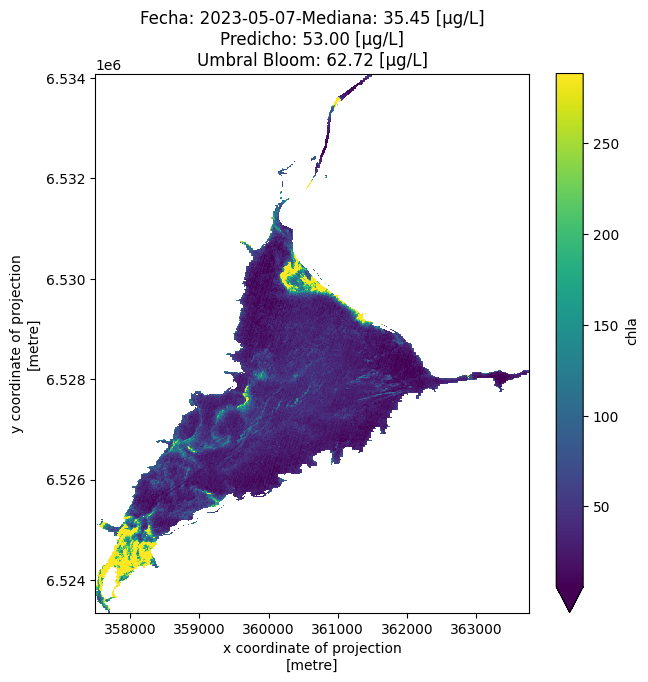

In [ ]:
# Ploteo del mapa de concentración de clorofila para la fecha más cercana
ds_chla_values = ds_chla.values



fig, ax = plt.subplots(figsize=(7, 7))
ds_chla.plot(ax=ax, vmin=np.nanpercentile(ds_chla_values, 1), vmax = np.nanpercentile(ds_chla_values, 99))
ax.set_title(f'Fecha: {ds_chla.attrs['scene_dates']}-Mediana: {np.nanmedian(ds_chla_values):.2f} [µg/L]\nPredicho: {predict_fecha[0]:.2f} [µg/L]\nUmbral Bloom: {umbral_bloom:.2f} [µg/L]')

##**4. Conclusiones**

La comparación de los modelos en tiempo real (nowcasting) confirma que el XGBoost supera al modelo lineal tanto en la reducción del error (RMSE menor) como en su capacidad de discriminación de eventos de bloom, debido a la naturaleza no lineal de la dinámica del fitoplancton frente a las variables meterológicas y de inercia.

En cuanto a la predicción anticipada a una semana, los modelos demostraron una capacidad predictiva moderada como herramientas de alerta temprana. Particularmente, la integración de los registros térmicos de las estaciones meteorológicas in situ (dataset híbrido) arrojó un desempeño métrico prácticamente idéntico al del modelo basado íntegramente en ERA5-Land. Esto evidencia que, si bien el uso de datos terrestres aporta flexibilidad operativa en tiempo real, la disponibilidad del retardo de primer orden de la temperatura local no modifica sustancialmente el rendimiento global del algoritmo frente al reanálisis.

Al contrastar los resultados nowcasting con los antecedentes de German (2025), quien obtuvo para XGBoost un R² de 0.81 y un RMSE de 11.35 $\mu$g/L utilizando una serie temporal más extensa (305 observaciones frente a las 154 de este estudio), se advierte que un mayor volumen de datos históricos incrementa la capacidad explicativa del algoritmo.

Aunque las validaciones secuenciales específicas para series temporales (TimeSeriesSplit) representan el estándar ideal, de haberlo aplicado para este estudio, la longitud acotada de la serie histórica habría reducido en exceso el entrenamiento inicial, castigando el aprendizaje del algoritmo. Por ello, se priorizó una validación aleatoria multisemilla ($85/15$), asegurando que el modelo aprendiera de la variabilidad disponible en toda la serie temporal.

## **5. Vinculación con la misión SABIA-Mar**

El modelo semiempírico utilizado para calcular la concentración de clorofila-a en el ESR utiliza la relación entre las bandas 8 (NIR, 842 nm) y 4 (Rojo, 665 nm) de Sentinel-2 (German, 2025). Considerando que las bandas 6 (665 nm) y 11 (865 nm) de la misión SABIA-Mar presentan especificaiones espectrales equivalentes a las utilizadas por Sentinel-2, será posible implementar este mismo modelo, aportando como valor agregado fundamental una mayor frecuencia de revisita (resolución temporal) en comparación con Sentinel-2.


Una vez generada una serie temporal de datos suficiente, estos podrán ser utilizados para desarrollar un modelo de forecasting de bloom algal en el Embalse San Roque, tal como se ha realizado a lo largo de este trabajo. Como variables explicativas se podrán utilizar datos de reanálisis de ERA5 y/o los registros de las estaciones meteorológicas del Proyecto MATTEO.

Complementariamente, se podrá explorar el uso de los datos del modelo [WRF generado por el Servicio Meteorológico Nacional (SMN)](https://odp-aws-smn.github.io/documentation_wrf_det/), con una resolución espacial de ~4 km.


## **6. Referencias bibliográficas**

* German, A. (2025). *Evaluación y desarrollo de herramientas geoespaciales para la gestión de la calidad de aguas interiores mediante la integración de información satelital y monitoreo de campo*. Tesis de Doctorado en Geomática y Sistemas Espaciales, Universidad Nacional de Córdoba (Instituto de Altos Estudios Espaciales "Mario Gulich" - CONAE).

*  Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *The Annals of Statistics*, 29(5), 1189–1232.

## **Enlaces notebooks complementarios**

Procesamiento imágenes S2-cla: https://drive.google.com/file/d/1jKyOA2sc6zoSTve95DHZDOfj-cf5_hyh/view?usp=sharing

Procesamiento datos meteorológicos (ERA5 + estaciones): https://drive.google.com/file/d/1zVKol6Y4Dz1zGtPdbjJqUJydIxAPJsrN/view?usp=sharing

Script pipeline get_inputs.py: https://drive.google.com/file/d/1UFew6sixU3EqYGeFuBhTsmjjYgeSe8-d/view?usp=sharing